# 1.Thư viện


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# 2. Kiểm tra file và đọc các file quan trọng

In [37]:
# Kiểm tra nhanh xem các file cần thiết đã có trong session Colab chưa
required_files = [
    "orders.csv",
    "order_items.csv",
    "sales.csv",
    "products.csv",
    "shipments.csv"
]

missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError("Thiếu các file sau: " + ", ".join(missing_files))

# Đọc dữ liệu
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(
    "order_items.csv",
    dtype={"promo_id": "string", "promo_id_2": "string"},
    low_memory=False
)
sales = pd.read_csv("sales.csv", parse_dates=["Date"])
products = pd.read_csv("products.csv")
shipments = pd.read_csv("shipments.csv", parse_dates=["ship_date", "delivery_date"])

print("Đọc dữ liệu thành công.\n")
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("sales:", sales.shape)
print("products:", products.shape)
print("shipments:", shipments.shape)

print("\nKhoảng ngày của sales:")
print(sales["Date"].min(), "->", sales["Date"].max())

print("\nCác trạng thái đơn hàng:")
print(orders["order_status"].value_counts())


Đọc dữ liệu thành công.

orders: (646945, 8)
order_items: (714669, 7)
sales: (3833, 3)
products: (2412, 8)
shipments: (566067, 4)

Khoảng ngày của sales:
2012-07-04 00:00:00 -> 2022-12-31 00:00:00

Các trạng thái đơn hàng:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


# 3. Tạo cột doanh thu

In [38]:
items = (
    order_items
    .merge(
        orders[[
            "order_id", "order_date", "order_status",
            "customer_id", "zip", "payment_method",
            "device_type", "order_source"
        ]],
        on="order_id",
        how="left"
    )
    .merge(
        products[[
            "product_id", "product_name", "category",
            "segment", "size", "price", "cogs"
        ]],
        on="product_id",
        how="left"
    )
    .merge(
        shipments[["order_id", "ship_date", "delivery_date", "shipping_fee"]],
        on="order_id",
        how="left"
    )
)

# Tạo các biến quan trọng
items["gross_revenue"] = items["quantity"] * items["unit_price"]
items["net_revenue"] = items["gross_revenue"] - items["discount_amount"]
items["line_cogs"] = items["quantity"] * items["cogs"]

print("Kích thước bảng items sau khi ghép:", items.shape)
display(items.head())

print("\nThống kê nhanh 3 cột quan trọng:")
display(items[["gross_revenue", "net_revenue", "line_cogs"]].describe())


Kích thước bảng items sau khi ghép: (714669, 26)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,order_status,customer_id,zip,payment_method,device_type,order_source,product_name,category,segment,size,price,cogs,ship_date,delivery_date,shipping_fee,gross_revenue,net_revenue,line_cogs
0,1,2400,7,"1,138.22",0.00,<NA>,<NA>,2012-07-04,delivered,58578,1109,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,"1,109.26","1,053.80",2012-07-07,2012-07-11,1.37,"7,967.54","7,967.54","7,376.59"
1,2,609,7,"10,166.25",0.00,<NA>,<NA>,2012-07-04,returned,58621,1330,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,"10,426.57","8,987.70",2012-07-06,2012-07-10,2.60,"71,163.75","71,163.75","62,913.93"
2,3,396,3,"11,220.33",0.00,<NA>,<NA>,2012-07-04,delivered,58811,1473,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,"11,028.43","10,091.01",2012-07-04,2012-07-07,2.38,"33,660.99","33,660.99","30,273.04"
3,4,635,5,"10,639.25",0.00,<NA>,<NA>,2012-07-04,delivered,59453,2360,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,"10,745.22","9,205.43",2012-07-05,2012-07-11,2.49,"53,196.25","53,196.25","46,027.15"
4,6,1935,1,"1,597.84",0.00,<NA>,<NA>,2012-07-06,delivered,57821,2886,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,"1,609.91","1,048.70",2012-07-09,2012-07-16,25.79,"1,597.84","1,597.84","1,048.70"



Thống kê nhanh 3 cột quan trọng:


,gross_revenue,net_revenue,line_cogs
count,"714,669.00","714,669.00","714,669.00"
mean,"22,990.33","21,941.44","19,818.20"
std,"22,352.46","21,712.28","19,987.24"
min,442.89,389.74,346.31
25%,"6,497.97","6,041.64","5,277.21"
50%,"15,442.12","14,518.07","13,013.78"
75%,"32,016.64","30,635.50","27,265.63"
max,"331,570.40","331,570.40","311,220.00"


gross_revenue: doanh thu gộp trước giảm giá

net_revenue: doanh thu sau giảm giá

line_cogs: giá vốn từ bảng sản phẩm

mean là giá trị trung bình mỗi dòng hàng

gross_revenue = 22,990.33

net_revenue = 21,941.44

line_cogs = 19,818.20

giảm giá trung bình mỗi dòng khoảng
22,990.33 - 21,941.44 = 1,048.89 đồng

chênh lệch giữa doanh thu gộp và giá vốn trung bình khoảng 22,990.33 - 19,818.20 = 3,172.13 đồng

doanh thu không phân bố đều, mà có những line item giá trị cao, ví dụ ở mean có giá trị gross_revenue	ở 22,990 nhưng ở giá trị trung bình 50% thì gross_revenue	lại chỉ là 15,442


# 4. So sánh sales.csv với doanh thu cộng theo order_date

In [39]:
daily_order = (
    items.groupby("order_date", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        cogs_from_items=("line_cogs", "sum")
    )
)

compare_order = sales.merge(
    daily_order,
    left_on="Date",
    right_on="order_date",
    how="left"
)

compare_order["diff_sales_vs_gross"] = compare_order["Revenue"] - compare_order["gross_revenue"]
compare_order["diff_sales_vs_net"] = compare_order["Revenue"] - compare_order["net_revenue"]
compare_order["diff_cogs"] = compare_order["COGS"] - compare_order["cogs_from_items"]

summary_compare = pd.DataFrame({
    "So sánh": [
        "Revenue của sales vs gross_revenue theo order_date",
        "Revenue của sales vs net_revenue theo order_date",
        "COGS của sales vs line_cogs theo order_date"
    ],
    "MAE": [
        np.abs(compare_order["diff_sales_vs_gross"]).mean(),
        np.abs(compare_order["diff_sales_vs_net"]).mean(),
        np.abs(compare_order["diff_cogs"]).mean()
    ],
    "Sai số lớn nhất": [
        np.abs(compare_order["diff_sales_vs_gross"]).max(),
        np.abs(compare_order["diff_sales_vs_net"]).max(),
        np.abs(compare_order["diff_cogs"]).max()
    ]
})

display(summary_compare)


,So sánh,MAE,Sai số lớn nhất
0,Revenue của sales vs gross_revenue theo order_...,0.00,0.00
1,Revenue của sales vs net_revenue theo order_date,"195,566.74","2,623,653.76"
2,COGS của sales vs line_cogs theo order_date,0.00,0.00


sales vs gross_revenue theo order_date có sai số gần 0: nên doanh thu ở trong bài này nó được tính theo ngày đặt hàng

sales vs net_revenue lệch lớn: nên cái sales.Revenue nó không phải là doanh thu sau khi giảm giá mà là doanh thu gộp lại trước khi giảm giá


tóm lại trong bài này có một số vấn đề:

doanh thu được tính sau khi đặt hàng

doanh thu được tính trước khi giảm giá

giá trị doanh thu chưa trừ lại các đơn bị cancelled

# 5. Xem trực quan 60 ngày đầu để cảm nhận mức độ khớp

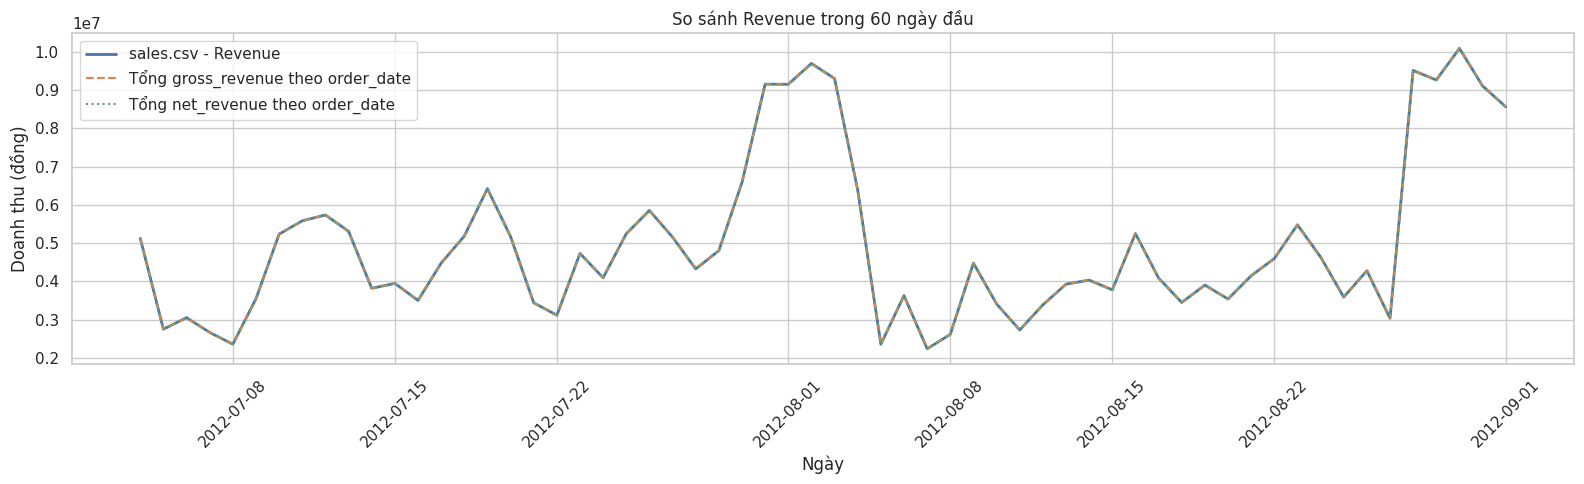

In [40]:
plot_df = compare_order.head(60).copy()

plt.figure(figsize=(16, 5))
plt.plot(plot_df["Date"], plot_df["Revenue"], label="sales.csv - Revenue", linewidth=2)
plt.plot(plot_df["Date"], plot_df["gross_revenue"], label="Tổng gross_revenue theo order_date", linestyle="--")
plt.plot(plot_df["Date"], plot_df["net_revenue"], label="Tổng net_revenue theo order_date", linestyle=":")
plt.title("So sánh Revenue trong 60 ngày đầu")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu (đồng)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


cái này vẽ ngu từ từ vẽ lại


# 6. So sánh nhiều giả thuyết ghi nhận doanh thu cùng lúc

In [41]:
def evaluate_hypothesis(label, date_col, revenue_col, allowed_status=None):
    df = items.copy()

    if allowed_status is not None:
        df = df[df["order_status"].isin(allowed_status)]

    df = df[df[date_col].notna()].copy()

    daily = (
        df.groupby(date_col, as_index=False)
        .agg(
            pred_revenue=(revenue_col, "sum"),
            pred_cogs=("line_cogs", "sum")
        )
    )

    merged = sales.merge(
        daily,
        left_on="Date",
        right_on=date_col,
        how="left"
    )

    merged[["pred_revenue", "pred_cogs"]] = merged[["pred_revenue", "pred_cogs"]].fillna(0)

    return {
        "Giả thuyết": label,
        "MAE Revenue": np.abs(merged["Revenue"] - merged["pred_revenue"]).mean(),
        "Sai số max Revenue": np.abs(merged["Revenue"] - merged["pred_revenue"]).max(),
        "MAE COGS": np.abs(merged["COGS"] - merged["pred_cogs"]).mean(),
        "Sai số max COGS": np.abs(merged["COGS"] - merged["pred_cogs"]).max(),
    }

results = pd.DataFrame([
    evaluate_hypothesis(
        label="order_date | gross | tất cả status",
        date_col="order_date",
        revenue_col="gross_revenue",
        allowed_status=None
    ),
    evaluate_hypothesis(
        label="order_date | net | tất cả status",
        date_col="order_date",
        revenue_col="net_revenue",
        allowed_status=None
    ),
    evaluate_hypothesis(
        label="order_date | gross | bỏ cancelled",
        date_col="order_date",
        revenue_col="gross_revenue",
        allowed_status=["created", "paid", "shipped", "delivered", "returned"]
    ),
    evaluate_hypothesis(
        label="ship_date | gross | shipped/delivered/returned",
        date_col="ship_date",
        revenue_col="gross_revenue",
        allowed_status=["shipped", "delivered", "returned"]
    ),
    evaluate_hypothesis(
        label="delivery_date | gross | chỉ delivered",
        date_col="delivery_date",
        revenue_col="gross_revenue",
        allowed_status=["delivered"]
    ),
])

results = results.sort_values("MAE Revenue")
display(results)


,Giả thuyết,MAE Revenue,Sai số max Revenue,MAE COGS,Sai số max COGS
0,order_date | gross | tất cả status,0.00,0.00,0.00,0.00
1,order_date | net | tất cả status,"195,566.74","2,623,653.76",0.00,0.00
2,order_date | gross | bỏ cancelled,"395,484.22","1,890,367.64","341,074.17","1,767,359.86"
3,ship_date | gross | shipped/delivered/returned,"986,568.19","10,365,656.87","860,476.83","8,200,911.83"
4,delivery_date | gross | chỉ delivered,"1,693,872.98","13,874,510.15","1,489,624.05","11,038,186.14"


Dòng 1: order_date | gross | tất cả status
Quy luật:

lấy quantity * unit_price
cộng theo order_date
giữ tất cả status
Kết quả sai số = 0

=> Đây là quy luật khớp hoàn toàn với sales.csv

Dòng 2: order_date | net | tất cả status
Quy luật:

lấy gross - discount
cộng theo order_date
giữ tất cả status
Kết quả sai số revenue lớn

=> sales.csv không dùng doanh thu sau giảm giá

Lưu ý:

MAE COGS = 0
vì đổi từ gross sang net chỉ làm thay đổi Revenue, không làm thay đổi COGS.

Dòng 3: order_date | gross | bỏ cancelled
Quy luật:

vẫn lấy gross revenue
vẫn theo order_date
nhưng bỏ các đơn cancelled
Kết quả vẫn sai số lớn

=> sales.csv có bao gồm cả phần giá trị từ đơn cancelled

Đây là chi tiết rất đáng khai thác.

Dòng 4: ship_date | gross | shipped/delivered/returned
Quy luật:

chỉ lấy các đơn đã đi vào luồng giao
cộng gross revenue theo ngày gửi hàng
Sai số lớn

=> sales.csv không ghi nhận theo ngày ship

Dòng 5: delivery_date | gross | chỉ delivered
Quy luật:

chỉ tính khi giao thành công
cộng theo ngày giao hàng
Sai số còn lớn hơn nữa

=> sales.csv lại càng không phải doanh thu kiểu “giao thành công mới ghi nhận”

# Kết luận

Trong bộ dữ liệu này, sales.csv đang hành xử như doanh thu gộp được ghi nhận theo ngày đặt hàng, và còn bao gồm cả đơn chưa hoàn tất thực tế như cancelled.

Nói cách khác:
đây không giống “doanh thu thực nhận sau fulfillment”
mà giống “giá trị bán hàng được booking tại thời điểm đặt đơn”

Vì thế:
shipped vs delivered rất đáng đào sâu, cancelled và returned là nơi tạo ra khoảng cách giữa “doanh thu được ghi nhận” và “doanh thu thật sự hoàn tất”

# 7. Payment_summary

In [42]:
payments = pd.read_csv("payments.csv")
shipments = pd.read_csv("shipments.csv", parse_dates=["ship_date", "delivery_date"])

order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"],
        net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"]
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_discount=("discount_amount", "sum")
    )
)

payment_check = (
    orders[["order_id", "order_status", "order_date"]]
    .merge(order_value, on="order_id", how="left")
    .merge(payments[["order_id", "payment_value", "payment_method", "installments"]], on="order_id", how="left")
    .merge(shipments[["order_id", "shipping_fee"]], on="order_id", how="left")
)

payment_check["shipping_fee"] = payment_check["shipping_fee"].fillna(0)

payment_check["diff_vs_gross"] = payment_check["payment_value"] - payment_check["gross_revenue"]
payment_check["diff_vs_net"] = payment_check["payment_value"] - payment_check["net_revenue"]
payment_check["diff_vs_net_plus_shipping"] = payment_check["payment_value"] - (
    payment_check["net_revenue"] + payment_check["shipping_fee"]
)
payment_check["diff_vs_gross_plus_shipping"] = payment_check["payment_value"] - (
    payment_check["gross_revenue"] + payment_check["shipping_fee"]
)

payment_summary = pd.DataFrame({
    "Giả thuyết": [
        "payment_value vs gross_revenue",
        "payment_value vs net_revenue",
        "payment_value vs net_revenue + shipping_fee",
        "payment_value vs gross_revenue + shipping_fee",
    ],
    "MAE": [
        payment_check["diff_vs_gross"].abs().mean(),
        payment_check["diff_vs_net"].abs().mean(),
        payment_check["diff_vs_net_plus_shipping"].abs().mean(),
        payment_check["diff_vs_gross_plus_shipping"].abs().mean(),
    ],
    "Sai số lớn nhất": [
        payment_check["diff_vs_gross"].abs().max(),
        payment_check["diff_vs_net"].abs().max(),
        payment_check["diff_vs_net_plus_shipping"].abs().max(),
        payment_check["diff_vs_gross_plus_shipping"].abs().max(),
    ]
}).sort_values("MAE")

display(payment_summary)


,Giả thuyết,MAE,Sai số lớn nhất
1,payment_value vs net_revenue,0.00,0.00
2,payment_value vs net_revenue + shipping_fee,4.34,32.00
0,payment_value vs gross_revenue,"1,158.69","37,183.16"
3,payment_value vs gross_revenue + shipping_fee,"1,163.03","37,186.12"


sales.csv phản ánh doanh thu gộp được ghi nhận, còn payments.csv phản ánh số tiền thực khách đã trả sau giảm giá.

# 8. refund_amount trong returns.csv

In [43]:
returns = pd.read_csv("returns.csv")

# Chuẩn bị bảng order_items ở mức dòng hàng
item_lines = (
    order_items
    .assign(
        gross_line_value=lambda df: df["quantity"] * df["unit_price"],
        net_line_value=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"],
        discount_per_unit=lambda df: df["discount_amount"] / df["quantity"]
    )
    .copy()
)

# Ước lượng giá trị phần hàng bị trả
# Giả định hoàn tiền theo số lượng trả trên cùng dòng sản phẩm trong đơn
returns_check = (
    returns
    .merge(
        item_lines[[
            "order_id", "product_id", "quantity",
            "unit_price", "gross_line_value", "net_line_value",
            "discount_per_unit"
        ]],
        on=["order_id", "product_id"],
        how="left"
    )
)

returns_check["gross_ref_est"] = returns_check["return_quantity"] * returns_check["unit_price"]
returns_check["net_ref_est"] = returns_check["return_quantity"] * (
    returns_check["unit_price"] - returns_check["discount_per_unit"]
)

returns_check["diff_refund_vs_gross_est"] = returns_check["refund_amount"] - returns_check["gross_ref_est"]
returns_check["diff_refund_vs_net_est"] = returns_check["refund_amount"] - returns_check["net_ref_est"]

refund_summary = pd.DataFrame({
    "Giả thuyết": [
        "refund_amount so với gross phần hàng bị trả",
        "refund_amount so với net phần hàng bị trả"
    ],
    "MAE": [
        returns_check["diff_refund_vs_gross_est"].abs().mean(),
        returns_check["diff_refund_vs_net_est"].abs().mean()
    ],
    "Sai số lớn nhất": [
        returns_check["diff_refund_vs_gross_est"].abs().max(),
        returns_check["diff_refund_vs_net_est"].abs().max()
    ]
}).sort_values("MAE")

display(refund_summary)


,Giả thuyết,MAE,Sai số lớn nhất
1,refund_amount so với net phần hàng bị trả,"1,041.35","19,971.55"
0,refund_amount so với gross phần hàng bị trả,"1,041.47","19,971.55"


In [44]:
refund_diagnostic = pd.DataFrame({
    "Chỉ số": [
        "Refund trung bình",
        "Sai số trung bình so với gross",
        "Sai số trung bình so với net",
        "Tỷ lệ sai số/gross_ref_est trung bình",
        "Tỷ lệ sai số/net_ref_est trung bình"
    ],
    "Giá trị": [
        returns_check["refund_amount"].mean(),
        returns_check["diff_refund_vs_gross_est"].abs().mean(),
        returns_check["diff_refund_vs_net_est"].abs().mean(),
        (returns_check["diff_refund_vs_gross_est"].abs() / returns_check["gross_ref_est"]).replace([np.inf, -np.inf], np.nan).mean(),
        (returns_check["diff_refund_vs_net_est"].abs() / returns_check["net_ref_est"]).replace([np.inf, -np.inf], np.nan).mean(),
    ]
})

display(refund_diagnostic)


,Chỉ số,Giá trị
0,Refund trung bình,"12,784.73"
1,Sai số trung bình so với gross,"1,041.47"
2,Sai số trung bình so với net,"1,041.35"
3,Tỷ lệ sai số/gross_ref_est trung bình,0.07
4,Tỷ lệ sai số/net_ref_est trung bình,0.08


chưa thể kết luận được việc refund_amount được hoàn theo doanh thu gộp trước hay sau giảm giá nên phần này bỏ qua

# 9. wrong_size có thực sự là lý do trả hàng lớn nhất?

In [45]:
returns_reason_summary = (
    returns.groupby("return_reason", as_index=False)
    .agg(
        so_luot_tra=("return_id", "count"),
        tong_so_luong_tra=("return_quantity", "sum"),
        tong_refund=("refund_amount", "sum"),
        refund_trung_binh=("refund_amount", "mean")
    )
)

returns_reason_summary["ty_trong_luot_tra_%"] = (
    returns_reason_summary["so_luot_tra"] / returns_reason_summary["so_luot_tra"].sum() * 100
)

returns_reason_summary["tong_refund_trieu"] = returns_reason_summary["tong_refund"] / 1e6

returns_reason_summary = returns_reason_summary.sort_values("so_luot_tra", ascending=False)

display(
    returns_reason_summary[
        [
            "return_reason",
            "so_luot_tra",
            "ty_trong_luot_tra_%",
            "tong_so_luong_tra",
            "tong_refund_trieu",
            "refund_trung_binh"
        ]
    ]
)


,return_reason,so_luot_tra,ty_trong_luot_tra_%,tong_so_luong_tra,tong_refund_trieu,refund_trung_binh
4,wrong_size,13967,34.97,38042,176.69,"12,650.33"
1,defective,8020,20.08,22274,103.60,"12,917.60"
3,not_as_described,7035,17.61,19358,90.65,"12,886.03"
0,changed_mind,6931,17.35,19144,89.72,"12,944.99"
2,late_delivery,3986,9.98,10768,49.94,"12,528.15"


Trả hàng do sai kích cỡ (wrong_size) là nguồn thất thoát lớn nhất, chiếm gần 35% tổng số lượt trả hàng và khoảng 176.69 triệu đồng hoàn tiền. Do mức hoàn tiền trung bình giữa các lý do khá tương đồng, thiệt hại chủ yếu đến từ tần suất phát sinh cao, cho thấy vấn đề nằm ở trải nghiệm chọn size hơn là ở giá trị đơn hàng.

In [46]:
wrong_size_by_category = (
    returns[returns["return_reason"] == "wrong_size"]
    .merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(
        so_luot_wrong_size=("return_id", "count"),
        tong_so_luong_tra=("return_quantity", "sum"),
        tong_refund=("refund_amount", "sum")
    )
)

wrong_size_by_category["ty_trong_%"] = (
    wrong_size_by_category["so_luot_wrong_size"]
    / wrong_size_by_category["so_luot_wrong_size"].sum()
    * 100
)

wrong_size_by_category["tong_refund_trieu"] = wrong_size_by_category["tong_refund"] / 1e6
wrong_size_by_category = wrong_size_by_category.sort_values("so_luot_wrong_size", ascending=False)

display(wrong_size_by_category[[
    "category",
    "so_luot_wrong_size",
    "ty_trong_%",
    "tong_so_luong_tra",
    "tong_refund_trieu"
]])


,category,so_luot_wrong_size,ty_trong_%,tong_so_luong_tra,tong_refund_trieu
3,Streetwear,7626,54.60,20744,140.35
2,Outdoor,5154,36.90,13957,27.36
1,GenZ,733,5.25,2098,4.02
0,Casual,454,3.25,1243,4.96


Streetwear và Outdoor chiếm tỉ trọng cao trong việc refund

In [47]:
wrong_size_streetwear_by_size = (
    returns[returns["return_reason"] == "wrong_size"]
    .merge(products[["product_id", "category", "size"]], on="product_id", how="left")
    .query("category == 'Streetwear'")
    .groupby("size", as_index=False)
    .agg(
        so_luot_wrong_size=("return_id", "count"),
        tong_so_luong_tra=("return_quantity", "sum"),
        tong_refund=("refund_amount", "sum")
    )
)

wrong_size_streetwear_by_size["ty_trong_%"] = (
    wrong_size_streetwear_by_size["so_luot_wrong_size"]
    / wrong_size_streetwear_by_size["so_luot_wrong_size"].sum()
    * 100
)

wrong_size_streetwear_by_size["tong_refund_trieu"] = wrong_size_streetwear_by_size["tong_refund"] / 1e6
wrong_size_streetwear_by_size = wrong_size_streetwear_by_size.sort_values("so_luot_wrong_size", ascending=False)

display(wrong_size_streetwear_by_size[[
    "size",
    "so_luot_wrong_size",
    "ty_trong_%",
    "tong_so_luong_tra",
    "tong_refund_trieu"
]])


,size,so_luot_wrong_size,ty_trong_%,tong_so_luong_tra,tong_refund_trieu
3,XL,2319,30.41,6378,47.19
2,S,1858,24.36,5094,32.45
1,M,1730,22.69,4771,30.56
0,L,1719,22.54,4501,30.15


Vấn đề sai kích cỡ không chỉ tập trung ở một size cụ thể, mà có vẻ là vấn đề rộng hơn ở cấp ngành hàng, đặc biệt là Streetwear và Outdoor. Trong riêng Streetwear, size XL cao nhất nhưng chưa vượt trội đủ mạnh để kết luận đây là một điểm lỗi riêng biệt; khả năng cao đây là vấn đề về trải nghiệm chọn size hoặc độ nhất quán form dáng trên nhiều size.

## thực sự thì Streetwear và Outdoor có phải là vấn đề hay không hay tính trên đầu số lượng bán ra thì nó là bình thường?


In [48]:
# Mẫu số: số dòng order_items theo category
sold_lines_by_category = (
    order_items
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .size()
    .rename(columns={"size": "so_dong_ban"})
)

# Tử số: số lượt wrong_size theo category
wrong_size_lines_by_category = (
    returns[returns["return_reason"] == "wrong_size"]
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .size()
    .rename(columns={"size": "so_luot_wrong_size"})
)

wrong_size_rate_by_category = (
    sold_lines_by_category
    .merge(wrong_size_lines_by_category, on="category", how="left")
    .fillna(0)
)

wrong_size_rate_by_category["ty_le_wrong_size_%"] = (
    wrong_size_rate_by_category["so_luot_wrong_size"]
    / wrong_size_rate_by_category["so_dong_ban"]
    * 100
)

wrong_size_rate_by_category = wrong_size_rate_by_category.sort_values(
    "ty_le_wrong_size_%", ascending=False
)

display(wrong_size_rate_by_category)


,category,so_dong_ban,so_luot_wrong_size,ty_le_wrong_size_%
2,Outdoor,259986,5154,1.98
1,GenZ,37159,733,1.97
3,Streetwear,393533,7626,1.94
0,Casual,23991,454,1.89


Streetwear có số lượt wrong_size lớn nhất một phần vì nó bán nhiều nhất, chứ không phải vì tỷ lệ sai size của nó cao bất thường.

Mặc dù tỷ lệ wrong-size theo từng ngành hàng không chênh lệch lớn, wrong_size vẫn là nguyên nhân trả hàng lớn nhất trong dữ liệu. Điều này cũng phù hợp với bối cảnh thương mại điện tử thời trang, nơi vấn đề size/fit thường là động lực trả hàng hàng đầu. Vì vậy, cải thiện trải nghiệm chọn size là một hướng can thiệp hợp lý để giảm thất thoát sau bán.

# 10. shipped và delivered khác nhau như thế nào

In [49]:
shipments = pd.read_csv("shipments.csv", parse_dates=["ship_date", "delivery_date"])

# Tạo giá trị đơn hàng ở mức order
order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"],
        net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"]
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum")
    )
)

# Ghép orders với shipments và order_value
status_check = (
    orders[["order_id", "order_date", "order_status"]]
    .merge(order_value, on="order_id", how="left")
    .merge(shipments[["order_id", "ship_date", "delivery_date", "shipping_fee"]], on="order_id", how="left")
)

status_check["days_to_ship"] = (status_check["ship_date"] - status_check["order_date"]).dt.days
status_check["days_ship_to_delivery"] = (status_check["delivery_date"] - status_check["ship_date"]).dt.days
status_check["days_total_delivery"] = (status_check["delivery_date"] - status_check["order_date"]).dt.days

status_focus = (
    status_check[status_check["order_status"].isin(["shipped", "delivered", "returned"])]
    .groupby("order_status", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        avg_days_to_ship=("days_to_ship", "mean"),
        median_days_to_ship=("days_to_ship", "median"),
        avg_days_ship_to_delivery=("days_ship_to_delivery", "mean"),
        median_days_ship_to_delivery=("days_ship_to_delivery", "median"),
        avg_days_total_delivery=("days_total_delivery", "mean"),
        median_days_total_delivery=("days_total_delivery", "median")
    )
)

status_focus["gross_revenue_ty"] = status_focus["gross_revenue"] / 1e9
status_focus["net_revenue_ty"] = status_focus["net_revenue"] / 1e9

display(status_focus)


,order_status,so_don,gross_revenue,net_revenue,avg_days_to_ship,median_days_to_ship,avg_days_ship_to_delivery,median_days_ship_to_delivery,avg_days_total_delivery,median_days_total_delivery,gross_revenue_ty,net_revenue_ty
0,delivered,516716,"13,117,091,360.41","12,518,175,957.20",1.50,1.00,4.50,4.00,6.00,6.00,13.12,12.52
1,returned,36142,"907,543,031.93","865,938,715.59",1.50,1.00,4.48,4.00,5.98,6.00,0.91,0.87
2,shipped,13773,"353,376,001.25","337,278,840.20",1.49,1.00,4.50,5.00,6.00,6.00,0.35,0.34


chưa thấy gì đặc biệt

In [50]:
shipped_time_check = (
    status_check[status_check["order_status"].isin(["shipped", "delivered", "returned"])]
    .assign(order_month=lambda df: df["order_date"].dt.to_period("M").astype(str))
    .groupby(["order_month", "order_status"], as_index=False)
    .agg(so_don=("order_id", "count"))
)

latest_months = sorted(shipped_time_check["order_month"].unique())[-12:]
display(shipped_time_check[shipped_time_check["order_month"].isin(latest_months)])


,order_month,order_status,so_don
342,2022-01,delivered,1329
343,2022-01,returned,100
344,2022-01,shipped,60
345,2022-02,delivered,1720
346,2022-02,returned,111
347,2022-02,shipped,50
348,2022-03,delivered,3255
349,2022-03,returned,223
350,2022-03,shipped,134
351,2022-04,delivered,3446


đéo hiểu

In [51]:
shipped_delivered_profile = (
    orders[orders["order_status"].isin(["shipped", "delivered"])]
    .groupby(["order_status", "payment_method"], as_index=False)
    .agg(so_don=("order_id", "count"))
)

# Tính tỷ trọng trong từng trạng thái
shipped_delivered_profile["ty_trong_trong_status_%"] = (
    shipped_delivered_profile["so_don"]
    / shipped_delivered_profile.groupby("order_status")["so_don"].transform("sum")
    * 100
)

display(
    shipped_delivered_profile.sort_values(["payment_method", "order_status"])
)


,order_status,payment_method,so_don,ty_trong_trong_status_%
0,delivered,apple_pay,52836,10.23
5,shipped,apple_pay,1405,10.20
1,delivered,bank_transfer,26263,5.08
6,shipped,bank_transfer,697,5.06
2,delivered,cod,67355,13.04
7,shipped,cod,2029,14.73
3,delivered,credit_card,291073,56.33
8,shipped,credit_card,7587,55.09
4,delivered,paypal,79189,15.33
9,shipped,paypal,2055,14.92


# 11. cancel_check

In [52]:
cancel_check = (
    orders[["order_id", "order_status"]]
    .merge(order_value, on="order_id", how="left")
    .groupby("order_status", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum")
    )
)

cancel_check["ty_trong_don_%"] = cancel_check["so_don"] / cancel_check["so_don"].sum() * 100
cancel_check["gross_revenue_ty"] = cancel_check["gross_revenue"] / 1e9
cancel_check["net_revenue_ty"] = cancel_check["net_revenue"] / 1e9

display(
    cancel_check[[
        "order_status",
        "so_don",
        "ty_trong_don_%",
        "gross_revenue_ty",
        "net_revenue_ty"
    ]].sort_values("gross_revenue_ty", ascending=False)
)


,order_status,so_don,ty_trong_don_%,gross_revenue_ty,net_revenue_ty
2,delivered,516716,79.87,13.12,12.52
0,cancelled,59462,9.19,1.52,1.45
4,returned,36142,5.59,0.91,0.87
5,shipped,13773,2.13,0.35,0.34
3,paid,13577,2.10,0.35,0.33
1,created,7275,1.12,0.19,0.18


cancelled > returned: thất thoát lớn nhất xảy ra trước khi đơn được hoàn tất, đơn bị hủy còn nhiều hơn là đơn hoàn trả

Dữ liệu cho thấy doanh thu được ghi nhận ngay tại thời điểm đặt đơn, nhưng một phần đáng kể không đi tới giao dịch hoàn tất. Riêng các đơn bị hủy (cancelled) chiếm 9.19% tổng số đơn và tương ứng khoảng 1.52 tỷ đồng gross revenue, lớn hơn cả giá trị của các đơn bị trả hàng (returned, khoảng 0.91 tỷ đồng). Điều này cho thấy phần thất thoát giá trị lớn nhất xảy ra trước giai đoạn hậu mãi.

In [53]:
cancel_by_payment = (
    orders[["order_id", "order_status", "payment_method"]]
    .merge(order_value, on="order_id", how="left")
    .groupby(["payment_method", "order_status"], as_index=False)
    .agg(
        so_don=("order_id", "count"),
        gross_revenue=("gross_revenue", "sum")
    )
)

# Pivot để dễ nhìn
cancel_pivot = cancel_by_payment.pivot(
    index="payment_method",
    columns="order_status",
    values="so_don"
).fillna(0)

# Tính tổng đơn và tỷ lệ cancelled theo payment_method
cancel_pivot["tong_don"] = cancel_pivot.sum(axis=1)
cancel_pivot["ty_le_cancelled_%"] = cancel_pivot["cancelled"] / cancel_pivot["tong_don"] * 100

cancel_pivot = cancel_pivot.sort_values("ty_le_cancelled_%", ascending=False)

display(cancel_pivot)


order_status,cancelled,created,delivered,paid,returned,shipped,tong_don,ty_le_cancelled_%
payment_method,,,,,,,,
cod,15468,1082,67355,2127,8620,2029,96681,16.00
paypal,7817,1090,79189,2026,4841,2055,97018,8.06
apple_pay,5190,732,52836,1331,3269,1405,64763,8.01
credit_card,28452,4028,291073,7405,17807,7587,356352,7.98
bank_transfer,2535,343,26263,688,1605,697,32131,7.89


In [54]:
cancel_rate_by_payment = (
    orders.groupby(["payment_method", "order_status"], as_index=False)
    .agg(so_don=("order_id", "count"))
    .pivot(index="payment_method", columns="order_status", values="so_don")
    .fillna(0)
)

cancel_rate_by_payment["tong_don"] = cancel_rate_by_payment.sum(axis=1)
cancel_rate_by_payment["ty_le_cancelled_%"] = (
    cancel_rate_by_payment["cancelled"] / cancel_rate_by_payment["tong_don"] * 100
)

result = (
    cancel_rate_by_payment.reset_index()[["payment_method", "cancelled", "tong_don", "ty_le_cancelled_%"]]
    .sort_values("ty_le_cancelled_%", ascending=False)
)

display(result)


order_status,payment_method,cancelled,tong_don,ty_le_cancelled_%
2,cod,15468,96681,16.00
4,paypal,7817,97018,8.06
0,apple_pay,5190,64763,8.01
3,credit_card,28452,356352,7.98
1,bank_transfer,2535,32131,7.89


Đơn bị hủy là nguồn thất thoát giá trị lớn nhất trước khi giao hàng. Đáng chú ý, đơn thanh toán bằng COD có tỷ lệ hủy 16.0%, gần gấp đôi các phương thức còn lại (xấp xỉ 8%). Điều này cho thấy rủi ro hủy đơn tập trung mạnh ở nhóm thanh toán khi nhận hàng.

In [55]:
cod_cancel_by_source = (
    orders[orders["payment_method"] == "cod"]
    .groupby(["order_source", "order_status"], as_index=False)
    .agg(so_don=("order_id", "count"))
    .pivot(index="order_source", columns="order_status", values="so_don")
    .fillna(0)
)

cod_cancel_by_source["tong_don"] = cod_cancel_by_source.sum(axis=1)
cod_cancel_by_source["ty_le_cancelled_%"] = (
    cod_cancel_by_source["cancelled"] / cod_cancel_by_source["tong_don"] * 100
)

result = (
    cod_cancel_by_source.reset_index()[["order_source", "cancelled", "tong_don", "ty_le_cancelled_%"]]
    .sort_values("ty_le_cancelled_%", ascending=False)
)

display(result)


order_status,order_source,cancelled,tong_don,ty_le_cancelled_%
1,email_campaign,1910,11615,16.44
4,referral,1560,9601,16.25
2,organic_search,4334,26883,16.12
0,direct,1250,7791,16.04
3,paid_search,3377,21211,15.92
5,social_media,3037,19580,15.51


Rủi ro huỷ cao của COD không phải là vấn đề của riêng một kênh marketing, mà là vấn đề mang tính hệ thống của chính phương thức thanh toán COD.

Một phát hiện quan trọng là phần thất thoát lớn nhất không đến từ trả hàng sau bán, mà từ các đơn bị hủy trước khi hoàn tất. Các đơn cancelled chiếm 9.19% tổng số đơn nhưng tương ứng khoảng 1.52 tỷ đồng gross revenue, lớn hơn cả giá trị của các đơn returned. Đáng chú ý, phương thức thanh toán COD có tỷ lệ hủy 16.0%, gần gấp đôi các phương thức còn lại (khoảng 8%), và mức này xuất hiện nhất quán trên hầu hết các nguồn đơn. Điều này cho thấy rủi ro hủy đơn của COD mang tính hệ thống hơn là do một kênh marketing riêng lẻ.

# 12. stockout

,category,so_ban_ghi,tong_ban_ra,stockout_days_tb,fill_rate_tb,ty_le_thang_stockout,sell_through_tb,ton_cuoi_ky_tb,ty_le_thang_stockout_%
0,GenZ,4674,48695,1.15,0.96,0.68,0.17,125.11,68.29
1,Outdoor,21050,337510,1.12,0.96,0.67,0.14,225.65,67.35
2,Streetwear,31020,511467,1.19,0.96,0.67,0.16,185.67,67.32
3,Casual,3503,31202,1.15,0.96,0.66,0.17,88.64,66.20


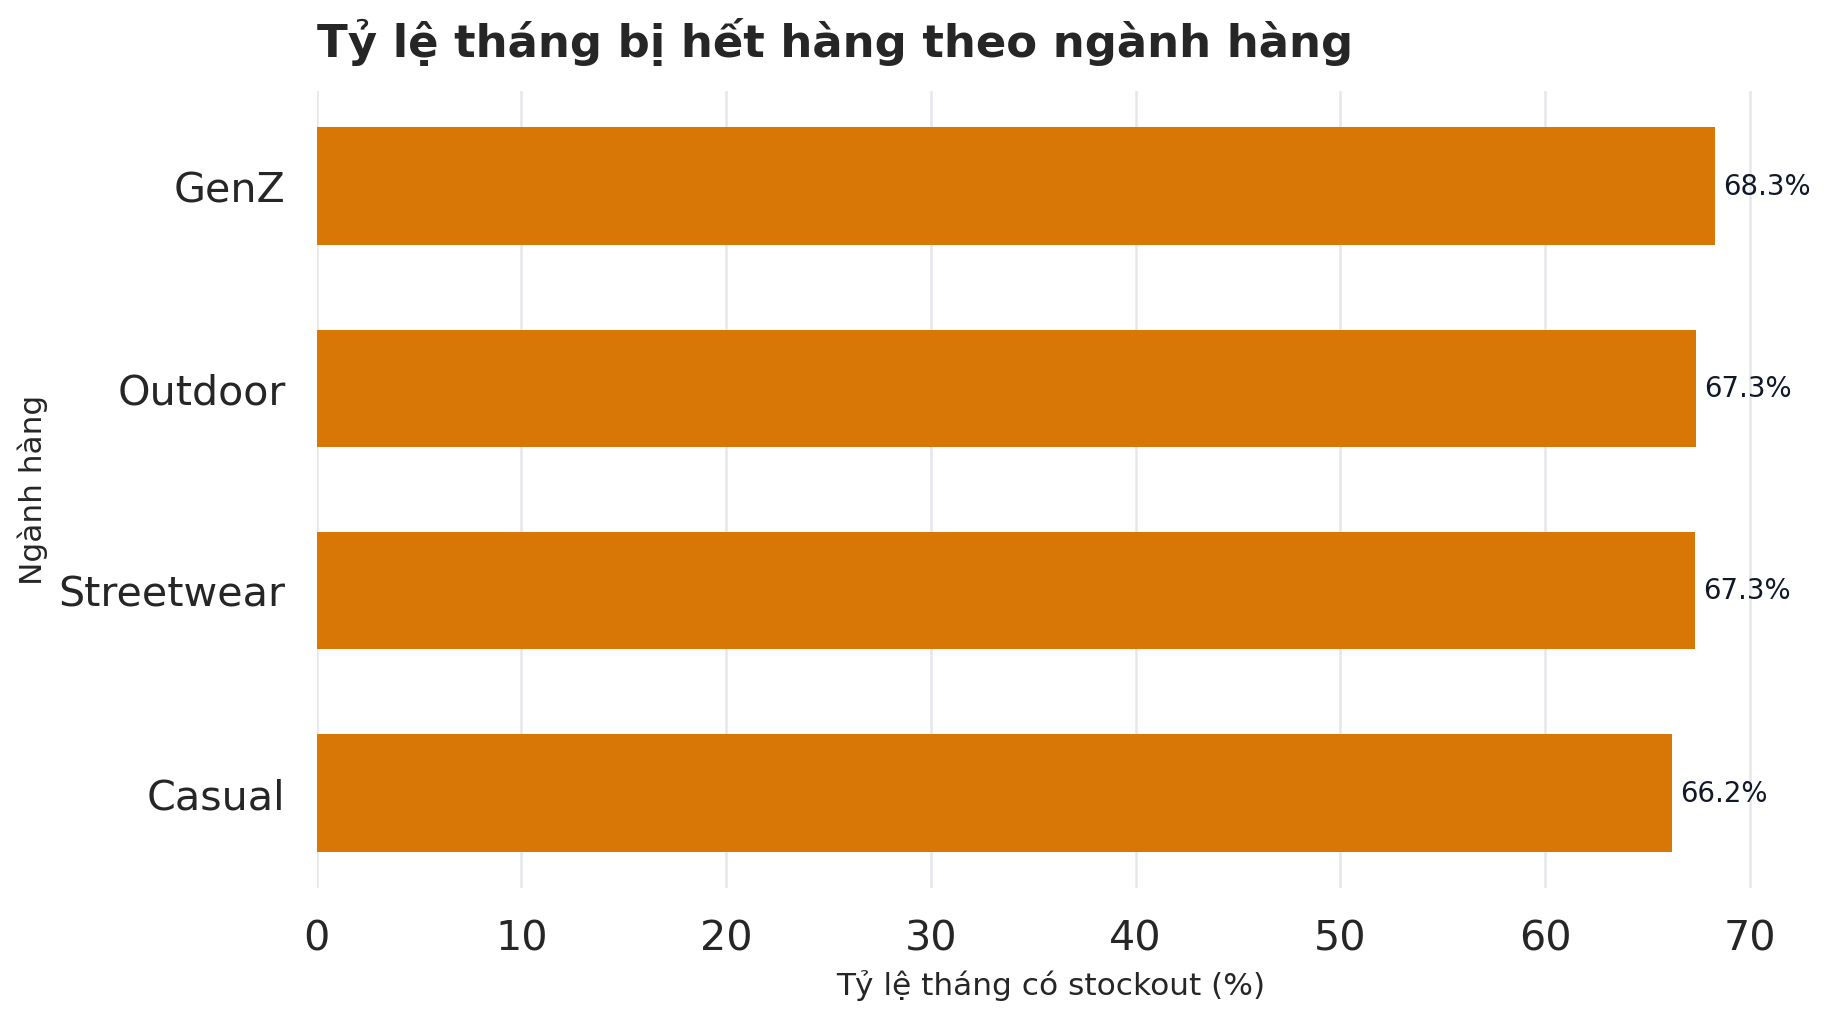

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc inventory nếu chưa có
inventory = pd.read_csv("inventory.csv", parse_dates=["snapshot_date"])

# Tổng hợp theo category
stockout_by_category = (
    inventory.groupby("category", as_index=False)
    .agg(
        so_ban_ghi=("product_id", "size"),
        tong_ban_ra=("units_sold", "sum"),
        stockout_days_tb=("stockout_days", "mean"),
        fill_rate_tb=("fill_rate", "mean"),
        ty_le_thang_stockout=("stockout_flag", "mean"),
        sell_through_tb=("sell_through_rate", "mean"),
        ton_cuoi_ky_tb=("stock_on_hand", "mean")
    )
)

stockout_by_category["ty_le_thang_stockout_%"] = stockout_by_category["ty_le_thang_stockout"] * 100
stockout_by_category = stockout_by_category.sort_values(
    ["ty_le_thang_stockout_%", "tong_ban_ra"], ascending=[False, False]
).reset_index(drop=True)

display(stockout_by_category)

# Vẽ biểu đồ: mức độ stockout theo category
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(10.5, 6), dpi=180)

bars = ax.barh(
    stockout_by_category["category"],
    stockout_by_category["ty_le_thang_stockout_%"],
    color="#D97706",
    edgecolor="none",
    height=0.58
)

ax.invert_yaxis()

for bar, value in zip(bars, stockout_by_category["ty_le_thang_stockout_%"]):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color="#111827"
    )

ax.set_title(
    "Tỷ lệ tháng bị hết hàng theo ngành hàng",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Tỷ lệ tháng có stockout (%)", fontsize=12.5)
ax.set_ylabel("Ngành hàng", fontsize=12.5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="x", color="#E5E7EB", linewidth=1)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


Tỷ lệ tháng có stockout giữa các category gần như giống nhau:

66.2% đến 68.3%

stockout_days_tb cũng gần như giống nhau:
quanh 1.12 - 1.19

fill_rate_tb đều khoảng 0.96

biểu đồ này chưa chỉ ra được category nào thực sự là điểm nghẽn nổi bật.

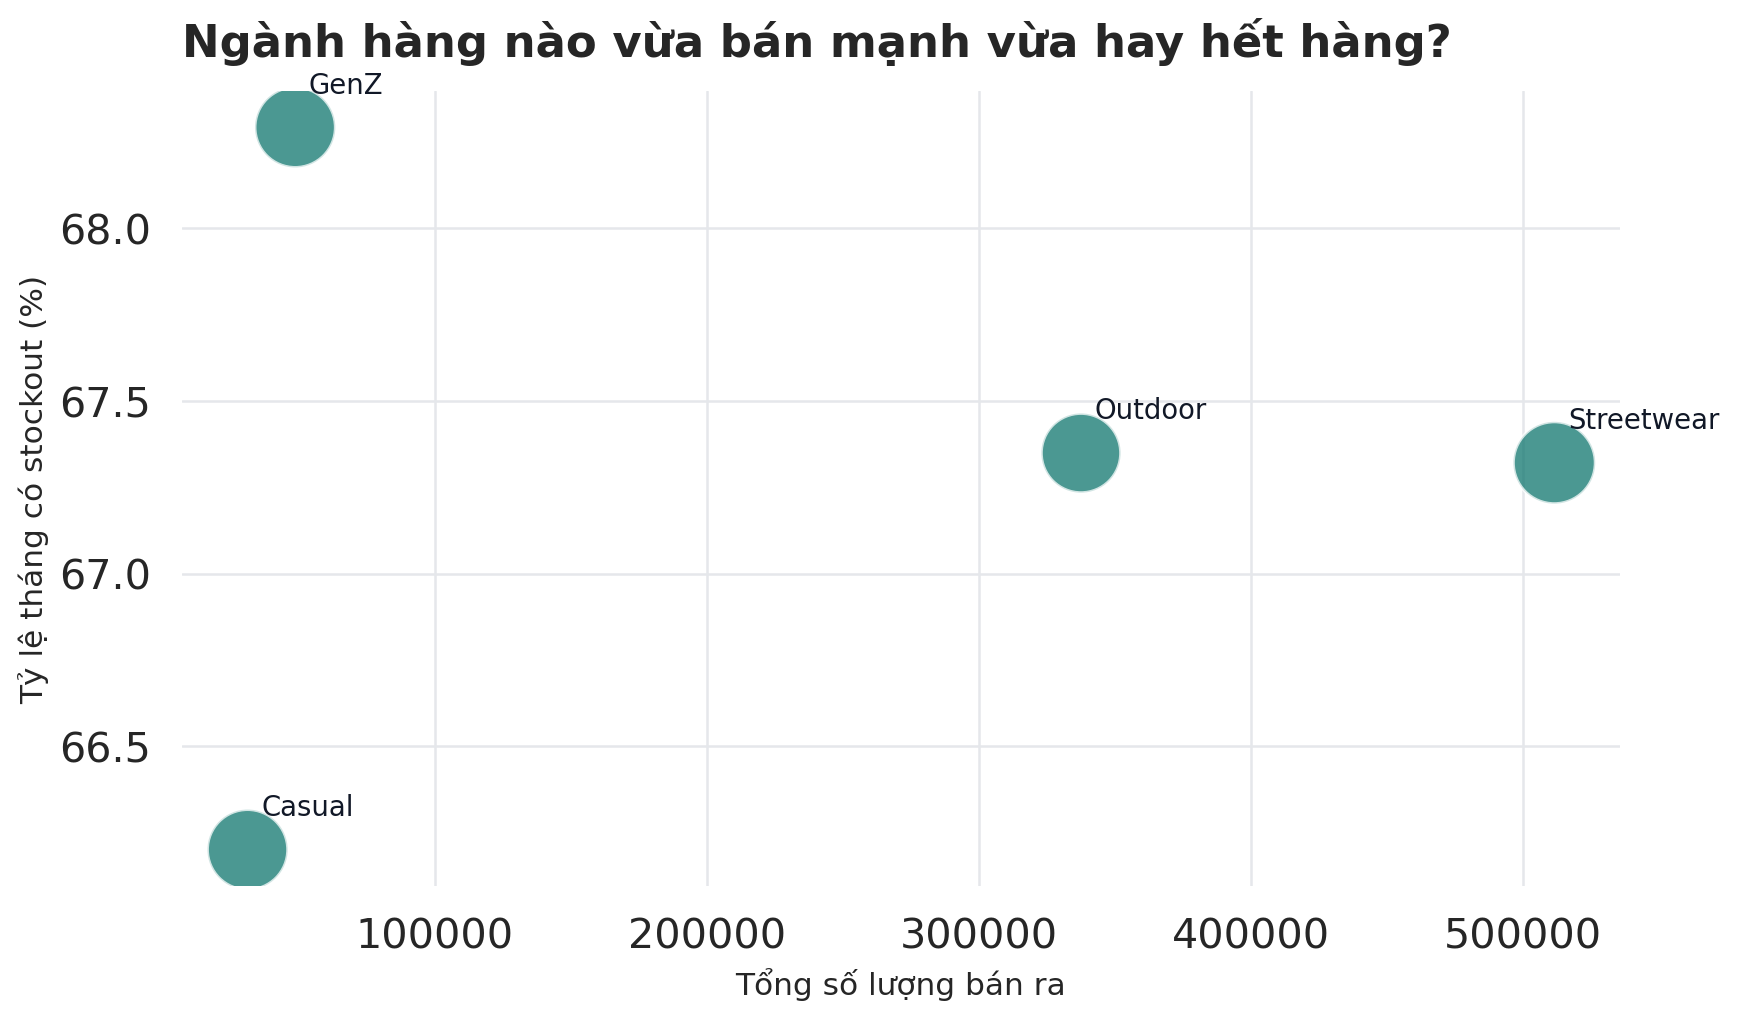

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = stockout_by_category.copy()

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)

scatter = ax.scatter(
    plot_df["tong_ban_ra"],
    plot_df["ty_le_thang_stockout_%"],
    s=plot_df["stockout_days_tb"] * 900,
    color="#0F766E",
    alpha=0.75,
    edgecolor="white",
    linewidth=1.2
)

for _, row in plot_df.iterrows():
    ax.text(
        row["tong_ban_ra"] + 5000,
        row["ty_le_thang_stockout_%"] + 0.1,
        row["category"],
        fontsize=11,
        color="#111827"
    )

ax.set_title(
    "Ngành hàng nào vừa bán mạnh vừa hay hết hàng?",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Tổng số lượng bán ra", fontsize=12.5)
ax.set_ylabel("Tỷ lệ tháng có stockout (%)", fontsize=12.5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="both", color="#E5E7EB", linewidth=1)

plt.tight_layout()
plt.show()


chưa có category nào đồng thời vừa bán cực mạnh vừa stockout cao vượt trội đến mức tạo ra một quyết định kinh doanh sắc nét.

# 12. Khuyến mãi có tăng doanh thu?

,nhom_promo,so_don,gross_revenue_ty,net_revenue_ty,discount_rate_%,aov_gross,aov_net,ty_le_huy_%,ty_le_giao_xong_%
0,Có khuyến mãi,248242,5.44,4.69,13.78,"21,914.45","18,894.78",9.22,79.85
1,Không khuyến mãi,398703,10.99,10.99,0.00,"27,565.36","27,565.36",9.17,79.88


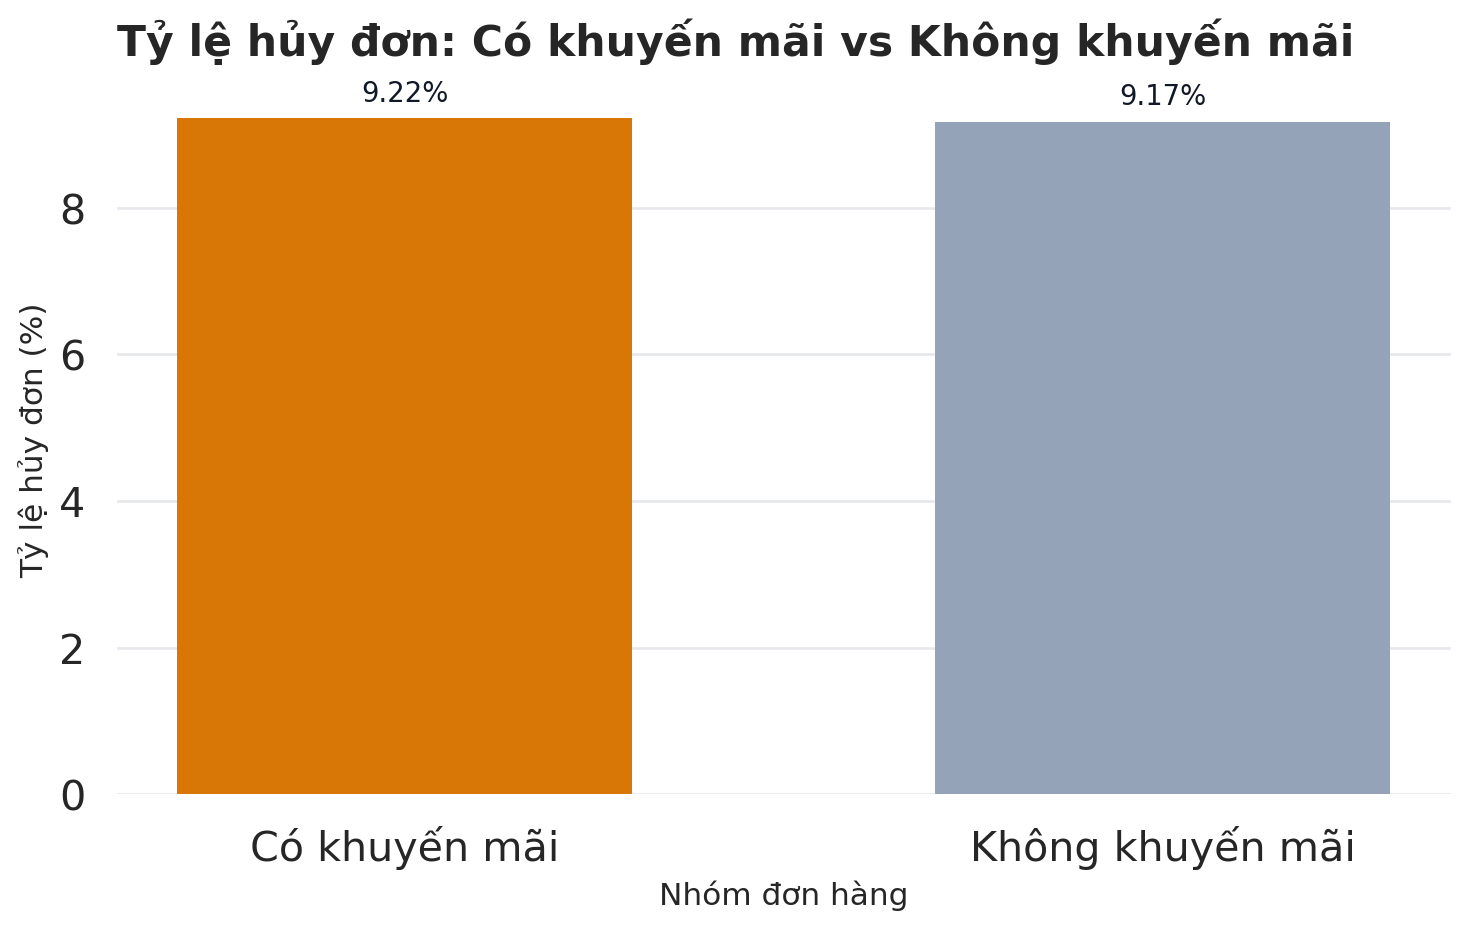

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nếu chưa đọc promotions thì đọc thêm cũng không sao
promotions = pd.read_csv("promotions.csv")

# =========================
# 1. Tạo bảng order-level có cờ dùng promo
# =========================
order_promo = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"],
        net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"],
        has_promo_line=lambda df: df["promo_id"].notna() | df["promo_id_2"].notna()
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_quantity=("quantity", "sum"),
        has_promo=("has_promo_line", "max")
    )
)

promo_orders = (
    orders[["order_id", "order_status", "order_date", "payment_method", "order_source"]]
    .merge(order_promo, on="order_id", how="left")
)

promo_orders["nhom_promo"] = promo_orders["has_promo"].map({
    True: "Có khuyến mãi",
    False: "Không khuyến mãi"
})

# =========================
# 2. Bảng so sánh chính
# =========================
promo_summary = (
    promo_orders.groupby("nhom_promo", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_discount=("total_discount", "sum"),
        aov_gross=("gross_revenue", "mean"),
        aov_net=("net_revenue", "mean"),
        ty_le_huy=("order_status", lambda s: (s == "cancelled").mean()),
        ty_le_giao_xong=("order_status", lambda s: (s == "delivered").mean())
    )
)

promo_summary["gross_revenue_ty"] = promo_summary["gross_revenue"] / 1e9
promo_summary["net_revenue_ty"] = promo_summary["net_revenue"] / 1e9
promo_summary["discount_rate_%"] = promo_summary["total_discount"] / promo_summary["gross_revenue"] * 100
promo_summary["ty_le_huy_%"] = promo_summary["ty_le_huy"] * 100
promo_summary["ty_le_giao_xong_%"] = promo_summary["ty_le_giao_xong"] * 100

display(
    promo_summary[[
        "nhom_promo",
        "so_don",
        "gross_revenue_ty",
        "net_revenue_ty",
        "discount_rate_%",
        "aov_gross",
        "aov_net",
        "ty_le_huy_%",
        "ty_le_giao_xong_%"
    ]]
)

# =========================
# 3. Biểu đồ phụ: so tỷ lệ hủy theo nhóm promo
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=180)

bars = ax.bar(
    promo_summary["nhom_promo"],
    promo_summary["ty_le_huy_%"],
    color=["#D97706", "#94A3B8"],
    edgecolor="none",
    width=0.6
)

for bar, value in zip(bars, promo_summary["ty_le_huy_%"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#111827"
    )

ax.set_title(
    "Tỷ lệ hủy đơn: Có khuyến mãi vs Không khuyến mãi",
    loc="left",
    fontsize=17,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Nhóm đơn hàng", fontsize=12.5)
ax.set_ylabel("Tỷ lệ hủy đơn (%)", fontsize=12.5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="y", color="#E5E7EB", linewidth=1)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


đéo khác gì nhau


# 13. Doanh thu theo mùa

,thang,doanh_thu_tb_ngay,doanh_thu_trung_vi_ngay,so_don_tb_ngay,thang_label,doanh_thu_tb_trieu
0,1,"2,591,154.60","2,416,732.69",95.00,T1,2.59
1,2,"3,480,800.78","3,242,762.87",124.22,T2,3.48
2,3,"4,928,185.47","4,606,234.99",185.29,T3,4.93
3,4,"6,532,951.88","5,795,217.08",247.78,T4,6.53
4,5,"6,575,416.35","6,067,768.61",238.53,T5,6.58
5,6,"6,427,108.65","5,826,463.10",240.90,T6,6.43
6,7,"4,659,789.37","4,379,419.25",185.73,T7,4.66
7,8,"4,441,193.49","3,646,382.12",192.99,T8,4.44
8,9,"3,797,825.60","3,604,251.20",148.65,T9,3.80
9,10,"3,302,725.22","3,172,297.01",117.02,T10,3.30


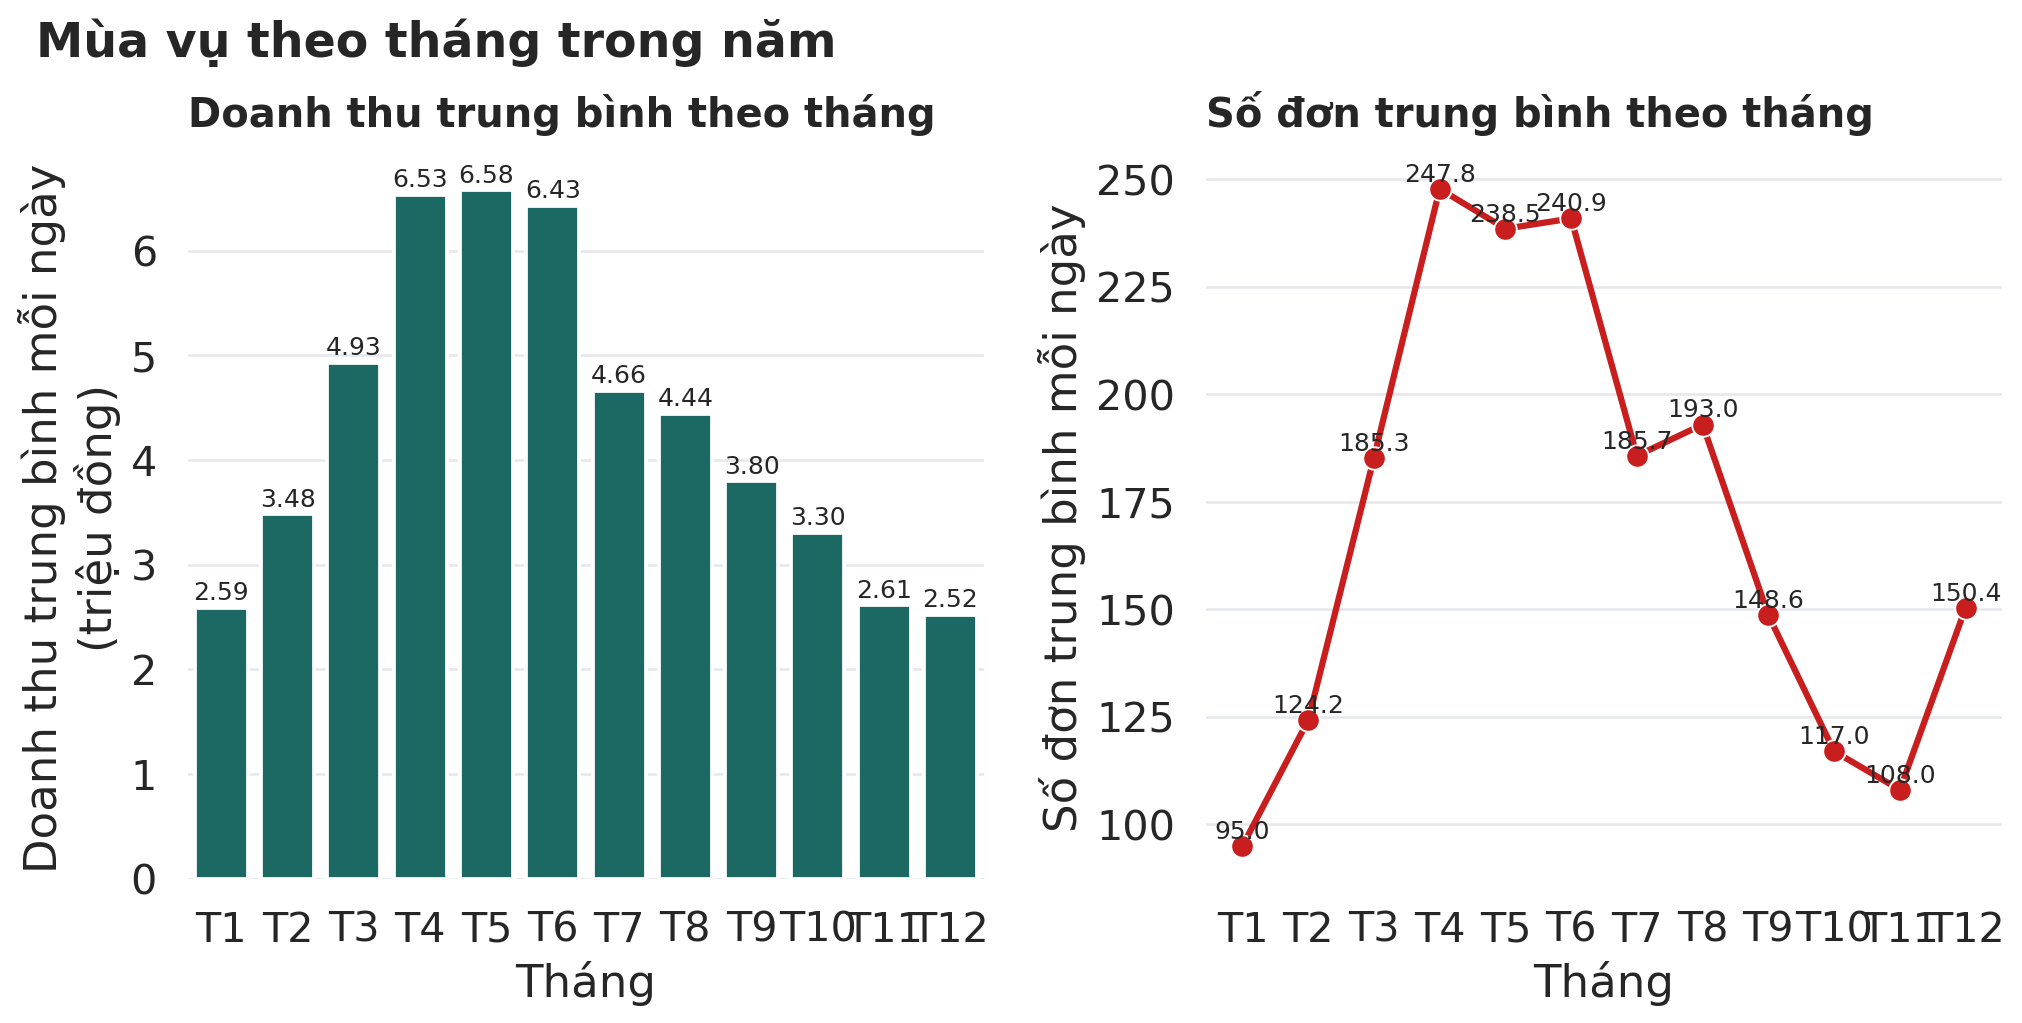

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nếu chưa có thì đọc lại
if "sales" not in globals():
    sales = pd.read_csv("sales.csv", parse_dates=["Date"])
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

# =========================
# 1. Chuẩn bị dữ liệu theo tháng trong năm
# =========================
month_labels = {
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
}

sales_month = sales.copy()
sales_month["thang"] = sales_month["Date"].dt.month
sales_month["nam"] = sales_month["Date"].dt.year

monthly_revenue_pattern = (
    sales_month.groupby("thang", as_index=False)
    .agg(
        doanh_thu_tb_ngay=("Revenue", "mean"),
        doanh_thu_trung_vi_ngay=("Revenue", "median")
    )
)

orders_month = orders.copy()
orders_month["thang"] = orders_month["order_date"].dt.month

monthly_order_pattern = (
    orders_month.groupby("thang", as_index=False)
    .agg(
        so_don_tb_ngay=("order_id", "count")
    )
)

# số đơn theo ngày trong từng tháng rồi lấy trung bình
daily_orders = (
    orders_month.groupby(["order_date", "thang"], as_index=False)
    .agg(so_don=("order_id", "count"))
)

monthly_order_pattern = (
    daily_orders.groupby("thang", as_index=False)
    .agg(so_don_tb_ngay=("so_don", "mean"))
)

plot_df = monthly_revenue_pattern.merge(monthly_order_pattern, on="thang", how="left")
plot_df["thang_label"] = plot_df["thang"].map(month_labels)
plot_df["doanh_thu_tb_trieu"] = plot_df["doanh_thu_tb_ngay"] / 1e6

display(plot_df)

# =========================
# 2. Vẽ biểu đồ
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=180)
plt.subplots_adjust(wspace=0.28, top=0.84)

# Biểu đồ 1: Doanh thu trung bình theo tháng
sns.barplot(
    data=plot_df,
    x="thang_label",
    y="doanh_thu_tb_trieu",
    color="#0F766E",
    ax=axes[0]
)

for i, v in enumerate(plot_df["doanh_thu_tb_trieu"]):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

axes[0].set_title("Doanh thu trung bình theo tháng", loc="left", fontsize=16, fontweight="bold", pad=12)
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Doanh thu trung bình mỗi ngày\n(triệu đồng)")

# Biểu đồ 2: Số đơn trung bình theo tháng
sns.lineplot(
    data=plot_df,
    x="thang_label",
    y="so_don_tb_ngay",
    marker="o",
    linewidth=2.5,
    color="#C81E1E",
    ax=axes[1]
)

for i, v in enumerate(plot_df["so_don_tb_ngay"]):
    axes[1].text(i, v + 0.6, f"{v:.1f}", ha="center", va="bottom", fontsize=10)

axes[1].set_title("Số đơn trung bình theo tháng", loc="left", fontsize=16, fontweight="bold", pad=12)
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Số đơn trung bình mỗi ngày")

for ax in axes:
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", color="#E5E7EB", linewidth=1)
    ax.grid(axis="x", visible=False)

plt.suptitle("Mùa vụ theo tháng trong năm", x=0.06, ha="left", fontsize=19, fontweight="bold")
plt.show()


Doanh thu và số đơn trung bình theo tháng cho thấy mùa vụ rất rõ: cả hai cùng tăng mạnh từ đầu năm và đạt đỉnh ở T4–T6, rồi giảm dần về cuối năm, thấp nhất ở T11–T1

,thang,so_don_tb_ngay,doanh_thu_tb_ngay,aov_gross_tb,aov_net_tb,thang_label,doanh_thu_tb_trieu,aov_gross_nghin,aov_net_nghin
0,1,95.00,"2,591,154.60","29,001.11","28,876.04",T1,2.59,29.00,28.88
1,2,124.22,"3,480,800.78","29,300.07","28,973.88",T2,3.48,29.30,28.97
2,3,185.29,"4,928,185.47","28,247.94","27,070.02",T3,4.93,28.25,27.07
3,4,247.78,"6,532,951.88","27,303.10","25,741.61",T4,6.53,27.30,25.74
4,5,238.53,"6,575,416.35","28,759.38","28,759.38",T5,6.58,28.76,28.76
5,6,240.90,"6,427,108.65","28,205.82","27,356.40",T6,6.43,28.21,27.36
6,7,185.73,"4,659,789.37","26,124.04","23,518.61",T7,4.66,26.12,23.52
7,8,192.99,"4,441,193.49","23,933.18","23,856.16",T8,4.44,23.93,23.86
8,9,148.65,"3,797,825.60","27,056.46","24,678.06",T9,3.80,27.06,24.68
9,10,117.02,"3,302,725.22","29,777.93","29,709.63",T10,3.30,29.78,29.71


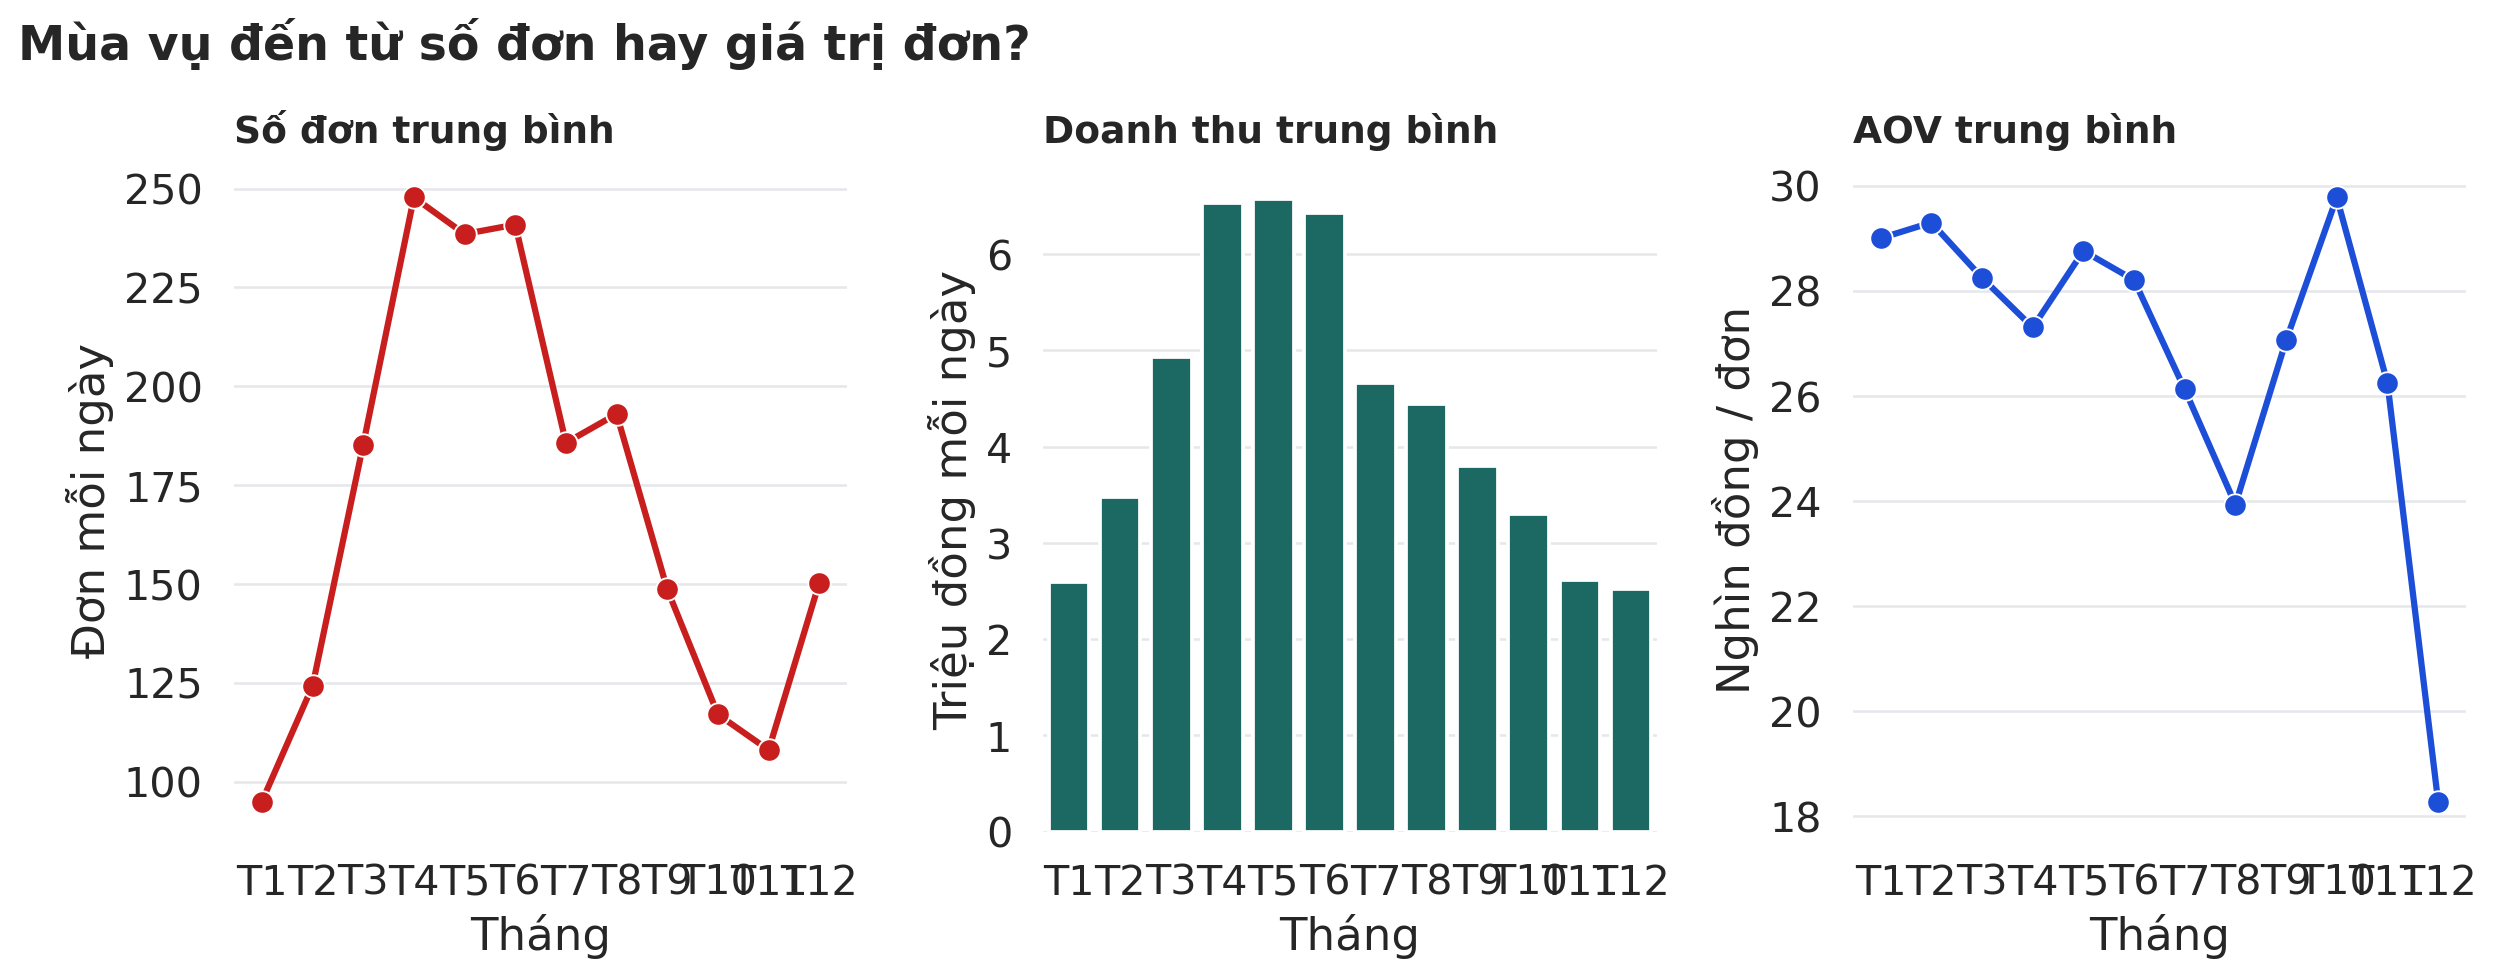

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Chuẩn bị dữ liệu order-level
# =========================
order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"],
        net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"]
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_quantity=("quantity", "sum")
    )
)

orders_month = (
    orders[["order_id", "order_date", "order_status"]]
    .merge(order_value, on="order_id", how="left")
    .copy()
)

orders_month["thang"] = orders_month["order_date"].dt.month
orders_month["nam"] = orders_month["order_date"].dt.year
orders_month["ngay"] = orders_month["order_date"].dt.date

# Chỉ số theo ngày
daily_stats = (
    orders_month.groupby(["ngay", "thang"], as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu_gross=("gross_revenue", "sum"),
        doanh_thu_net=("net_revenue", "sum")
    )
)

daily_stats["aov_gross"] = daily_stats["doanh_thu_gross"] / daily_stats["so_don"]
daily_stats["aov_net"] = daily_stats["doanh_thu_net"] / daily_stats["so_don"]

# Tổng hợp theo tháng trong năm
month_labels = {
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
}

seasonality_decomp = (
    daily_stats.groupby("thang", as_index=False)
    .agg(
        so_don_tb_ngay=("so_don", "mean"),
        doanh_thu_tb_ngay=("doanh_thu_gross", "mean"),
        aov_gross_tb=("aov_gross", "mean"),
        aov_net_tb=("aov_net", "mean")
    )
)

seasonality_decomp["thang_label"] = seasonality_decomp["thang"].map(month_labels)
seasonality_decomp["doanh_thu_tb_trieu"] = seasonality_decomp["doanh_thu_tb_ngay"] / 1e6
seasonality_decomp["aov_gross_nghin"] = seasonality_decomp["aov_gross_tb"] / 1e3
seasonality_decomp["aov_net_nghin"] = seasonality_decomp["aov_net_tb"] / 1e3

display(seasonality_decomp)

# =========================
# 2. Vẽ 3 góc nhìn cùng lúc
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), dpi=180)
plt.subplots_adjust(wspace=0.32, top=0.82)

# Số đơn
sns.lineplot(
    data=seasonality_decomp,
    x="thang_label", y="so_don_tb_ngay",
    marker="o", linewidth=2.5, color="#C81E1E", ax=axes[0]
)
axes[0].set_title("Số đơn trung bình", loc="left", fontsize=15, fontweight="bold", pad=10)
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Đơn mỗi ngày")

# Doanh thu
sns.barplot(
    data=seasonality_decomp,
    x="thang_label", y="doanh_thu_tb_trieu",
    color="#0F766E", ax=axes[1]
)
axes[1].set_title("Doanh thu trung bình", loc="left", fontsize=15, fontweight="bold", pad=10)
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Triệu đồng mỗi ngày")

# AOV
sns.lineplot(
    data=seasonality_decomp,
    x="thang_label", y="aov_gross_nghin",
    marker="o", linewidth=2.5, color="#1D4ED8", ax=axes[2]
)
axes[2].set_title("AOV trung bình", loc="left", fontsize=15, fontweight="bold", pad=10)
axes[2].set_xlabel("Tháng")
axes[2].set_ylabel("Nghìn đồng / đơn")

for ax in axes:
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", color="#E5E7EB", linewidth=1)
    ax.grid(axis="x", visible=False)

plt.suptitle("Mùa vụ đến từ số đơn hay giá trị đơn?", x=0.05, ha="left", fontsize=19, fontweight="bold")
plt.show()


Mùa vụ doanh thu của doanh nghiệp được dẫn động chủ yếu bởi số đơn hàng chứ không phải bởi biến động lớn trong giá trị mỗi đơn. Doanh thu và số đơn cùng đạt đỉnh ở T4–T6, rồi giảm rõ về T11–T12, trong khi AOV phần lớn chỉ dao động nhẹ quanh 26–29 nghìn đồng/đơn, ngoại trừ nhịp giảm mạnh ở T12. Điều này cho thấy mô hình forecasting cần học rõ yếu tố mùa vụ theo tháng, còn về vận hành, doanh nghiệp nên tăng chuẩn bị tồn kho và năng lực xử lý đơn trong quý 2, đồng thời kiểm soát chất lượng doanh thu ở giai đoạn cuối năm.

,year,month,doanh_thu_tb_ngay,so_don_tb_ngay,aov_tb,rev_index,order_index,aov_index
0,2012,7,"4,657,384.77",189.07,"25,310.13",1.14,1.07,1.05
1,2012,8,"5,131,910.98",207.32,"24,971.98",1.25,1.17,1.04
2,2012,9,"4,310,237.79",173.97,"25,174.84",1.05,0.98,1.04
3,2012,10,"3,554,377.24",138.23,"26,215.88",0.87,0.78,1.09
4,2012,11,"3,272,876.51",138.07,"24,578.76",0.80,0.78,1.02
5,2012,12,"3,687,826.15",215.61,"18,503.78",0.90,1.22,0.77
6,2013,1,"2,945,441.19",118.23,"25,939.74",0.65,0.56,1.16
7,2013,2,"3,920,826.35",166.46,"24,321.15",0.86,0.79,1.09
8,2013,3,"4,897,892.17",212.58,"24,594.68",1.08,1.01,1.10
9,2013,4,"6,630,897.74",295.80,"22,608.42",1.46,1.41,1.01


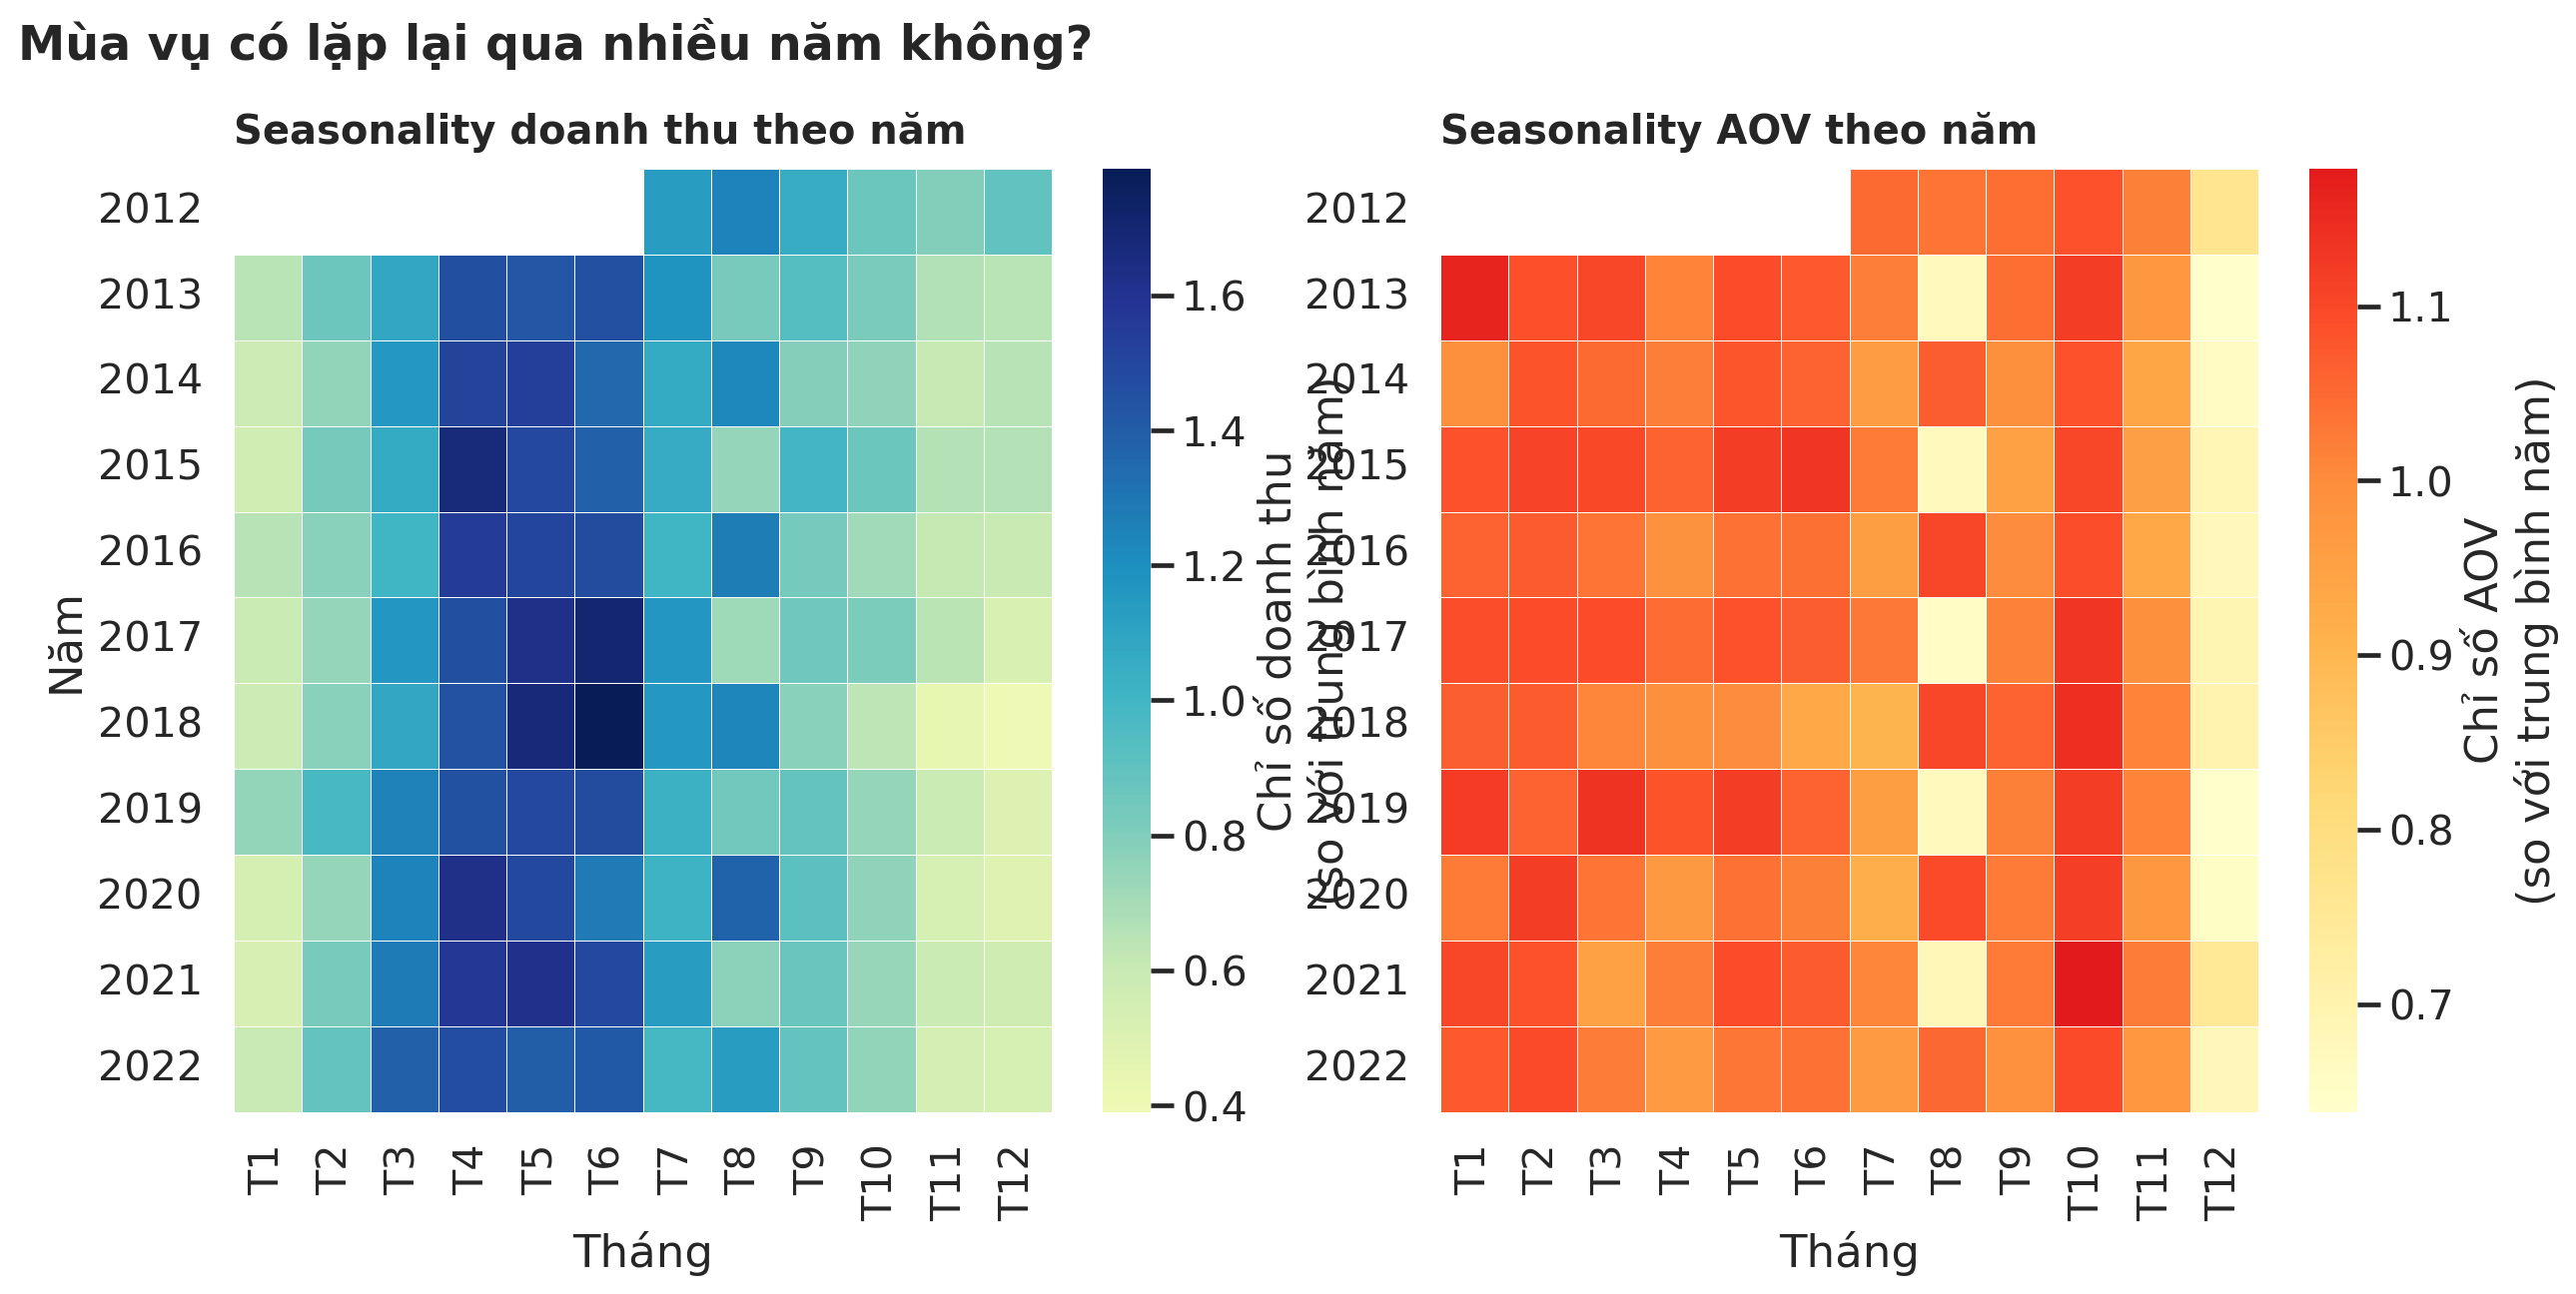

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Chuẩn bị dữ liệu theo năm-tháng
# =========================
# Nếu chưa có sales/orders thì đọc lại
if "sales" not in globals():
    sales = pd.read_csv("sales.csv", parse_dates=["Date"])
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

# Tạo order-level revenue nếu chưa có
order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"]
    )
    .groupby("order_id", as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"))
)

orders_full = (
    orders[["order_id", "order_date"]]
    .merge(order_value, on="order_id", how="left")
    .copy()
)

orders_full["year"] = orders_full["order_date"].dt.year
orders_full["month"] = orders_full["order_date"].dt.month
orders_full["day"] = orders_full["order_date"].dt.date

# Chỉ số theo ngày
daily_orders = (
    orders_full.groupby(["day", "year", "month"], as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

daily_orders["aov"] = daily_orders["doanh_thu"] / daily_orders["so_don"]

# Tổng hợp theo năm-tháng
monthly_yearly = (
    daily_orders.groupby(["year", "month"], as_index=False)
    .agg(
        doanh_thu_tb_ngay=("doanh_thu", "mean"),
        so_don_tb_ngay=("so_don", "mean"),
        aov_tb=("aov", "mean")
    )
)

# Chuẩn hóa trong từng năm để nhìn seasonality rõ hơn
monthly_yearly["rev_index"] = (
    monthly_yearly["doanh_thu_tb_ngay"]
    / monthly_yearly.groupby("year")["doanh_thu_tb_ngay"].transform("mean")
)

monthly_yearly["order_index"] = (
    monthly_yearly["so_don_tb_ngay"]
    / monthly_yearly.groupby("year")["so_don_tb_ngay"].transform("mean")
)

monthly_yearly["aov_index"] = (
    monthly_yearly["aov_tb"]
    / monthly_yearly.groupby("year")["aov_tb"].transform("mean")
)

# Pivot để vẽ heatmap
rev_pivot = monthly_yearly.pivot(index="year", columns="month", values="rev_index")
order_pivot = monthly_yearly.pivot(index="year", columns="month", values="order_index")
aov_pivot = monthly_yearly.pivot(index="year", columns="month", values="aov_index")

# Đổi nhãn tháng
month_labels = {
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
}
rev_pivot = rev_pivot.rename(columns=month_labels)
order_pivot = order_pivot.rename(columns=month_labels)
aov_pivot = aov_pivot.rename(columns=month_labels)

display(monthly_yearly.head(20))

# =========================
# 2. Vẽ heatmap
# =========================
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=180)
plt.subplots_adjust(wspace=0.18, top=0.86)

sns.heatmap(
    rev_pivot,
    cmap="YlGnBu",
    center=1,
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Chỉ số doanh thu\n(so với trung bình năm)"},
    ax=axes[0]
)
axes[0].set_title("Seasonality doanh thu theo năm", loc="left", fontsize=16, fontweight="bold", pad=10)
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Năm")

sns.heatmap(
    aov_pivot,
    cmap="YlOrRd",
    center=1,
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Chỉ số AOV\n(so với trung bình năm)"},
    ax=axes[1]
)
axes[1].set_title("Seasonality AOV theo năm", loc="left", fontsize=16, fontweight="bold", pad=10)
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("")

plt.suptitle("Mùa vụ có lặp lại qua nhiều năm không?", x=0.05, ha="left", fontsize=19, fontweight="bold")
plt.show()


Mùa vụ doanh thu của doanh nghiệp lặp lại khá ổn định qua nhiều năm, với giai đoạn cao điểm tập trung ở T4–T6 và giai đoạn thấp điểm rơi vào T11–T12. Điều này cho thấy seasonality là cấu trúc bền vững của dữ liệu chứ không phải biến động ngẫu nhiên theo từng năm. Trong khi đó, AOV có pattern yếu hơn nhưng vẫn cho thấy xu hướng suy giảm ở T8 và đặc biệt T12, hàm ý rằng giai đoạn cuối năm không chỉ có ít đơn hơn mà còn có giá trị đơn thấp hơn. Vì vậy, mô hình forecasting cần bắt buộc xử lý seasonality theo tháng, còn về vận hành, doanh nghiệp nên chuẩn bị năng lực phục vụ cao điểm vào quý 2 và đồng thời kiểm soát chất lượng doanh thu ở cuối năm.

,month,discount_rate_pct,promo_line_rate,avg_net_per_item
0,1,0.85,0.08,"5,293.62"
1,2,1.25,0.22,"5,537.07"
2,3,6.15,0.56,"5,050.41"
3,4,5.12,0.45,"5,109.47"
4,5,0.00,0.00,"5,660.53"
5,6,3.90,0.26,"5,263.06"
6,7,9.26,0.57,"4,684.71"
7,8,0.36,0.27,"4,677.50"
8,9,8.34,0.84,"4,759.55"
9,10,0.29,0.04,"5,679.55"


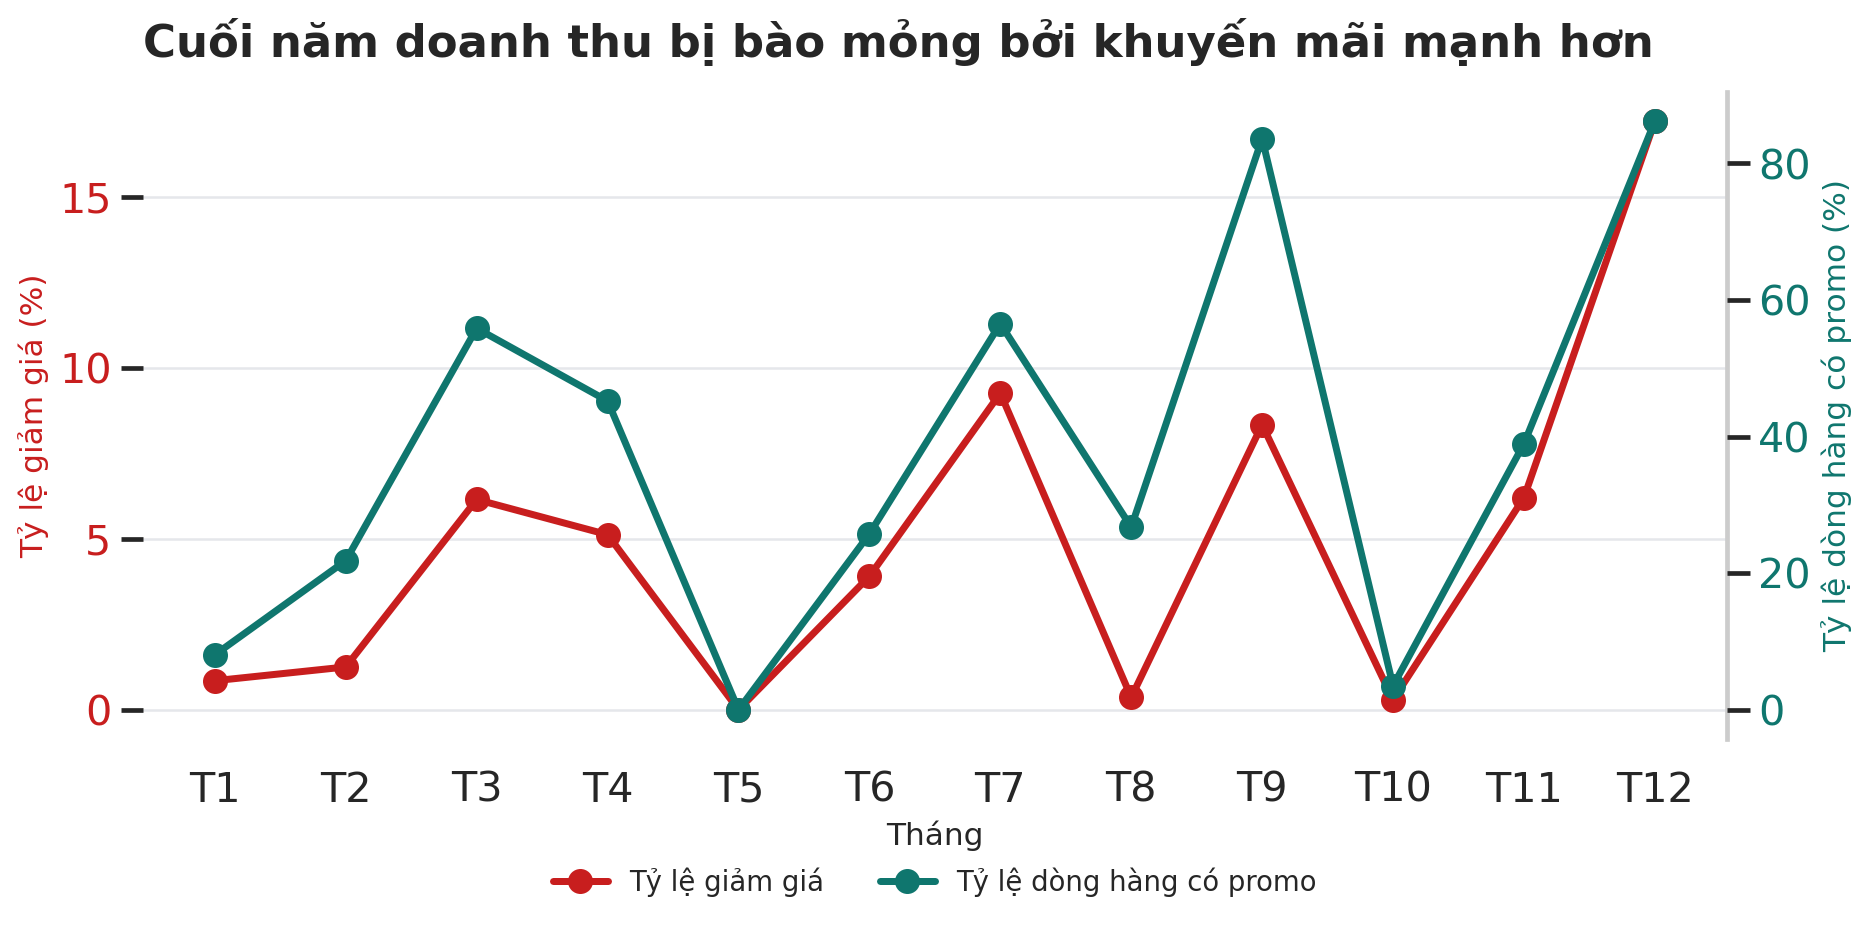

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Chuẩn bị dữ liệu theo tháng
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

items = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
).copy()

items["month"] = items["order_date"].dt.month
items["gross"] = items["quantity"] * items["unit_price"]
items["net"] = items["gross"] - items["discount_amount"]
items["has_promo"] = items["promo_id"].notna() | items["promo_id_2"].notna()

monthly = (
    items.groupby("month", as_index=False)
    .agg(
        gross=("gross", "sum"),
        net=("net", "sum"),
        discount=("discount_amount", "sum"),
        qty=("quantity", "sum"),
        promo_line_rate=("has_promo", "mean")
    )
)

monthly["discount_rate_pct"] = monthly["discount"] / monthly["gross"] * 100
monthly["avg_net_per_item"] = monthly["net"] / monthly["qty"]
monthly["thang_label"] = monthly["month"].map({
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
})

display(monthly[["month", "discount_rate_pct", "promo_line_rate", "avg_net_per_item"]])

# =========================
# 2. Vẽ biểu đồ
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax1 = plt.subplots(figsize=(11, 5.8), dpi=180)
plt.subplots_adjust(left=0.10, right=0.90, top=0.84, bottom=0.22)

x = range(len(monthly))

# Trục trái: tỷ lệ giảm giá
ax1.plot(
    x, monthly["discount_rate_pct"],
    marker="o", linewidth=2.8, color="#C81E1E", label="Tỷ lệ giảm giá"
)
ax1.set_ylabel("Tỷ lệ giảm giá (%)", color="#C81E1E", fontsize=12.5)
ax1.tick_params(axis="y", labelcolor="#C81E1E")

# Trục phải: tỷ lệ line có promo
ax2 = ax1.twinx()
ax2.plot(
    x, monthly["promo_line_rate"] * 100,
    marker="o", linewidth=2.8, color="#0F766E", label="Tỷ lệ dòng hàng có promo"
)
ax2.set_ylabel("Tỷ lệ dòng hàng có promo (%)", color="#0F766E", fontsize=12.5)
ax2.tick_params(axis="y", labelcolor="#0F766E")

ax1.set_title(
    "Cuối năm doanh thu bị bào mỏng bởi khuyến mãi mạnh hơn",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=14
)

ax1.set_xlabel("Tháng", fontsize=12.5)
ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly["thang_label"])

for ax in [ax1, ax2]:
    ax.grid(False)

ax1.grid(axis="y", color="#E5E7EB", linewidth=1)

for spine in ["top", "left", "bottom"]:
    ax1.spines[spine].set_visible(False)
for spine in ["top", "right", "left", "bottom"]:
    ax2.spines[spine].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.show()


T12 là tháng doanh thu không chỉ thấp về số đơn mà còn yếu về chất lượng: tỷ lệ giảm giá đạt 17.21%, hơn 86% dòng hàng có khuyến mãi, khiến giá trị thuần trên mỗi item giảm còn khoảng 2,566 đồng. Điều này cho thấy phần trũng cuối năm không chỉ là bài toán nhu cầu, mà còn là bài toán phụ thuộc quá mạnh vào khuyến mãi.

In [63]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# =========================
# 1. Đọc dữ liệu nếu cần
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

# =========================
# 2. Tạo dữ liệu tháng: doanh thu, số đơn, AOV
# =========================
order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"],
        net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"]
    )
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum")
    )
)

orders_full = (
    orders[["order_id", "order_date"]]
    .merge(order_value, on="order_id", how="left")
)

orders_full["ngay"] = orders_full["order_date"].dt.date
orders_full["thang"] = orders_full["order_date"].dt.month

daily_stats = (
    orders_full.groupby(["ngay", "thang"], as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

daily_stats["aov"] = daily_stats["doanh_thu"] / daily_stats["so_don"]

seasonality_summary = (
    daily_stats.groupby("thang", as_index=False)
    .agg(
        doanh_thu_tb_ngay=("doanh_thu", "mean"),
        so_don_tb_ngay=("so_don", "mean"),
        aov_tb=("aov", "mean")
    )
)

# =========================
# 3. Thêm discount / promo theo tháng
# =========================
items = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

items["thang"] = items["order_date"].dt.month
items["gross"] = items["quantity"] * items["unit_price"]
items["net"] = items["gross"] - items["discount_amount"]
items["has_promo"] = items["promo_id"].notna() | items["promo_id_2"].notna()

monthly_promo = (
    items.groupby("thang", as_index=False)
    .agg(
        gross=("gross", "sum"),
        net=("net", "sum"),
        discount=("discount_amount", "sum"),
        qty=("quantity", "sum"),
        promo_line_rate=("has_promo", "mean")
    )
)

monthly_promo["discount_rate_pct"] = monthly_promo["discount"] / monthly_promo["gross"] * 100
monthly_promo["avg_net_per_item"] = monthly_promo["net"] / monthly_promo["qty"]
monthly_promo["promo_line_rate_pct"] = monthly_promo["promo_line_rate"] * 100

seasonality_summary = seasonality_summary.merge(
    monthly_promo[["thang", "discount_rate_pct", "promo_line_rate_pct", "avg_net_per_item"]],
    on="thang",
    how="left"
)

seasonality_summary["thang_label"] = seasonality_summary["thang"].map({
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
})

seasonality_summary["doanh_thu_tb_trieu"] = seasonality_summary["doanh_thu_tb_ngay"] / 1e6
seasonality_summary["aov_tb_nghin"] = seasonality_summary["aov_tb"] / 1e3

# =========================
# 4. Rút số liệu chốt
# =========================
peak_rev = seasonality_summary.loc[seasonality_summary["doanh_thu_tb_ngay"].idxmax()]
low_rev = seasonality_summary.loc[seasonality_summary["doanh_thu_tb_ngay"].idxmin()]

peak_orders = seasonality_summary.loc[seasonality_summary["so_don_tb_ngay"].idxmax()]
low_orders = seasonality_summary.loc[seasonality_summary["so_don_tb_ngay"].idxmin()]

peak_aov = seasonality_summary.loc[seasonality_summary["aov_tb"].idxmax()]
low_aov = seasonality_summary.loc[seasonality_summary["aov_tb"].idxmin()]

corr_rev_orders = seasonality_summary["doanh_thu_tb_ngay"].corr(seasonality_summary["so_don_tb_ngay"])
corr_rev_aov = seasonality_summary["doanh_thu_tb_ngay"].corr(seasonality_summary["aov_tb"])

key_numbers = pd.DataFrame({
    "Chỉ số": [
        "Tháng doanh thu cao nhất",
        "Tháng doanh thu thấp nhất",
        "Mức tăng doanh thu cao/thấp",
        "Mức tăng số đơn cao/thấp",
        "Mức tăng AOV cao/thấp",
        "Tương quan doanh thu - số đơn",
        "Tương quan doanh thu - AOV",
        "Tỷ lệ giảm giá T12",
        "Tỷ lệ dòng hàng có promo T12",
        "Net/item T12"
    ],
    "Giá trị": [
        f"{peak_rev['thang_label']} ({peak_rev['doanh_thu_tb_trieu']:.2f} triệu/ngày)",
        f"{low_rev['thang_label']} ({low_rev['doanh_thu_tb_trieu']:.2f} triệu/ngày)",
        f"{peak_rev['doanh_thu_tb_ngay'] / low_rev['doanh_thu_tb_ngay']:.2f} lần",
        f"{peak_orders['so_don_tb_ngay'] / low_orders['so_don_tb_ngay']:.2f} lần",
        f"{peak_aov['aov_tb'] / low_aov['aov_tb']:.2f} lần",
        f"{corr_rev_orders:.2f}",
        f"{corr_rev_aov:.2f}",
        f"{seasonality_summary.loc[seasonality_summary['thang'] == 12, 'discount_rate_pct'].iloc[0]:.2f}%",
        f"{seasonality_summary.loc[seasonality_summary['thang'] == 12, 'promo_line_rate_pct'].iloc[0]:.2f}%",
        f"{seasonality_summary.loc[seasonality_summary['thang'] == 12, 'avg_net_per_item'].iloc[0]:,.0f} đồng"
    ]
})

display(seasonality_summary[[
    "thang_label",
    "doanh_thu_tb_trieu",
    "so_don_tb_ngay",
    "aov_tb_nghin",
    "discount_rate_pct",
    "promo_line_rate_pct",
    "avg_net_per_item"
]])

display(key_numbers)


,thang_label,doanh_thu_tb_trieu,so_don_tb_ngay,aov_tb_nghin,discount_rate_pct,promo_line_rate_pct,avg_net_per_item
0,T1,2.59,95.00,29.00,0.85,8.05,"5,293.62"
1,T2,3.48,124.22,29.30,1.25,21.83,"5,537.07"
2,T3,4.93,185.29,28.25,6.15,55.86,"5,050.41"
3,T4,6.53,247.78,27.30,5.12,45.22,"5,109.47"
4,T5,6.58,238.53,28.76,0.00,0.00,"5,660.53"
5,T6,6.43,240.90,28.21,3.90,25.76,"5,263.06"
6,T7,4.66,185.73,26.12,9.26,56.55,"4,684.71"
7,T8,4.44,192.99,23.93,0.36,26.75,"4,677.50"
8,T9,3.80,148.65,27.06,8.34,83.65,"4,759.55"
9,T10,3.30,117.02,29.78,0.29,3.51,"5,679.55"


,Chỉ số,Giá trị
0,Tháng doanh thu cao nhất,T5 (6.58 triệu/ngày)
1,Tháng doanh thu thấp nhất,T12 (2.52 triệu/ngày)
2,Mức tăng doanh thu cao/thấp,2.60 lần
3,Mức tăng số đơn cao/thấp,2.61 lần
4,Mức tăng AOV cao/thấp,1.63 lần
5,Tương quan doanh thu - số đơn,0.95
6,Tương quan doanh thu - AOV,0.30
7,Tỷ lệ giảm giá T12,17.21%
8,Tỷ lệ dòng hàng có promo T12,86.17%
9,Net/item T12,"2,566 đồng"


# 14. web_traffic.csv

,year,sessions_tb_ngay,so_don_tb_ngay,doanh_thu_tb_ngay,don_tren_1000_sessions,sessions_tb_ngay_idx,so_don_tb_ngay_idx,don_tren_1000_sessions_idx
0,2013,"18,635.45",210.55,"4,540,190.18",11.65,100.00,100.00,100.00
1,2014,"20,112.22",220.95,"5,128,344.88",11.32,107.92,104.94,97.17
2,2015,"21,539.56",226.36,"5,177,900.90",10.82,115.58,107.51,92.87
3,2016,"22,960.11",224.72,"5,750,384.36",10.06,123.21,106.73,86.33
4,2017,"24,637.27",208.25,"5,236,066.64",8.52,132.21,98.91,73.13
5,2018,"25,794.75",190.44,"5,068,828.65",7.16,138.42,90.45,61.44
6,2019,"27,370.27",113.98,"3,114,524.50",4.28,146.87,54.13,36.72
7,2020,"28,937.38",95.30,"2,881,180.76",3.30,155.28,45.26,28.29
8,2021,"30,114.32",94.59,"2,857,643.34",3.14,161.60,44.93,26.94
9,2022,"30,311.39",98.64,"3,204,791.32",3.31,162.65,46.85,28.43


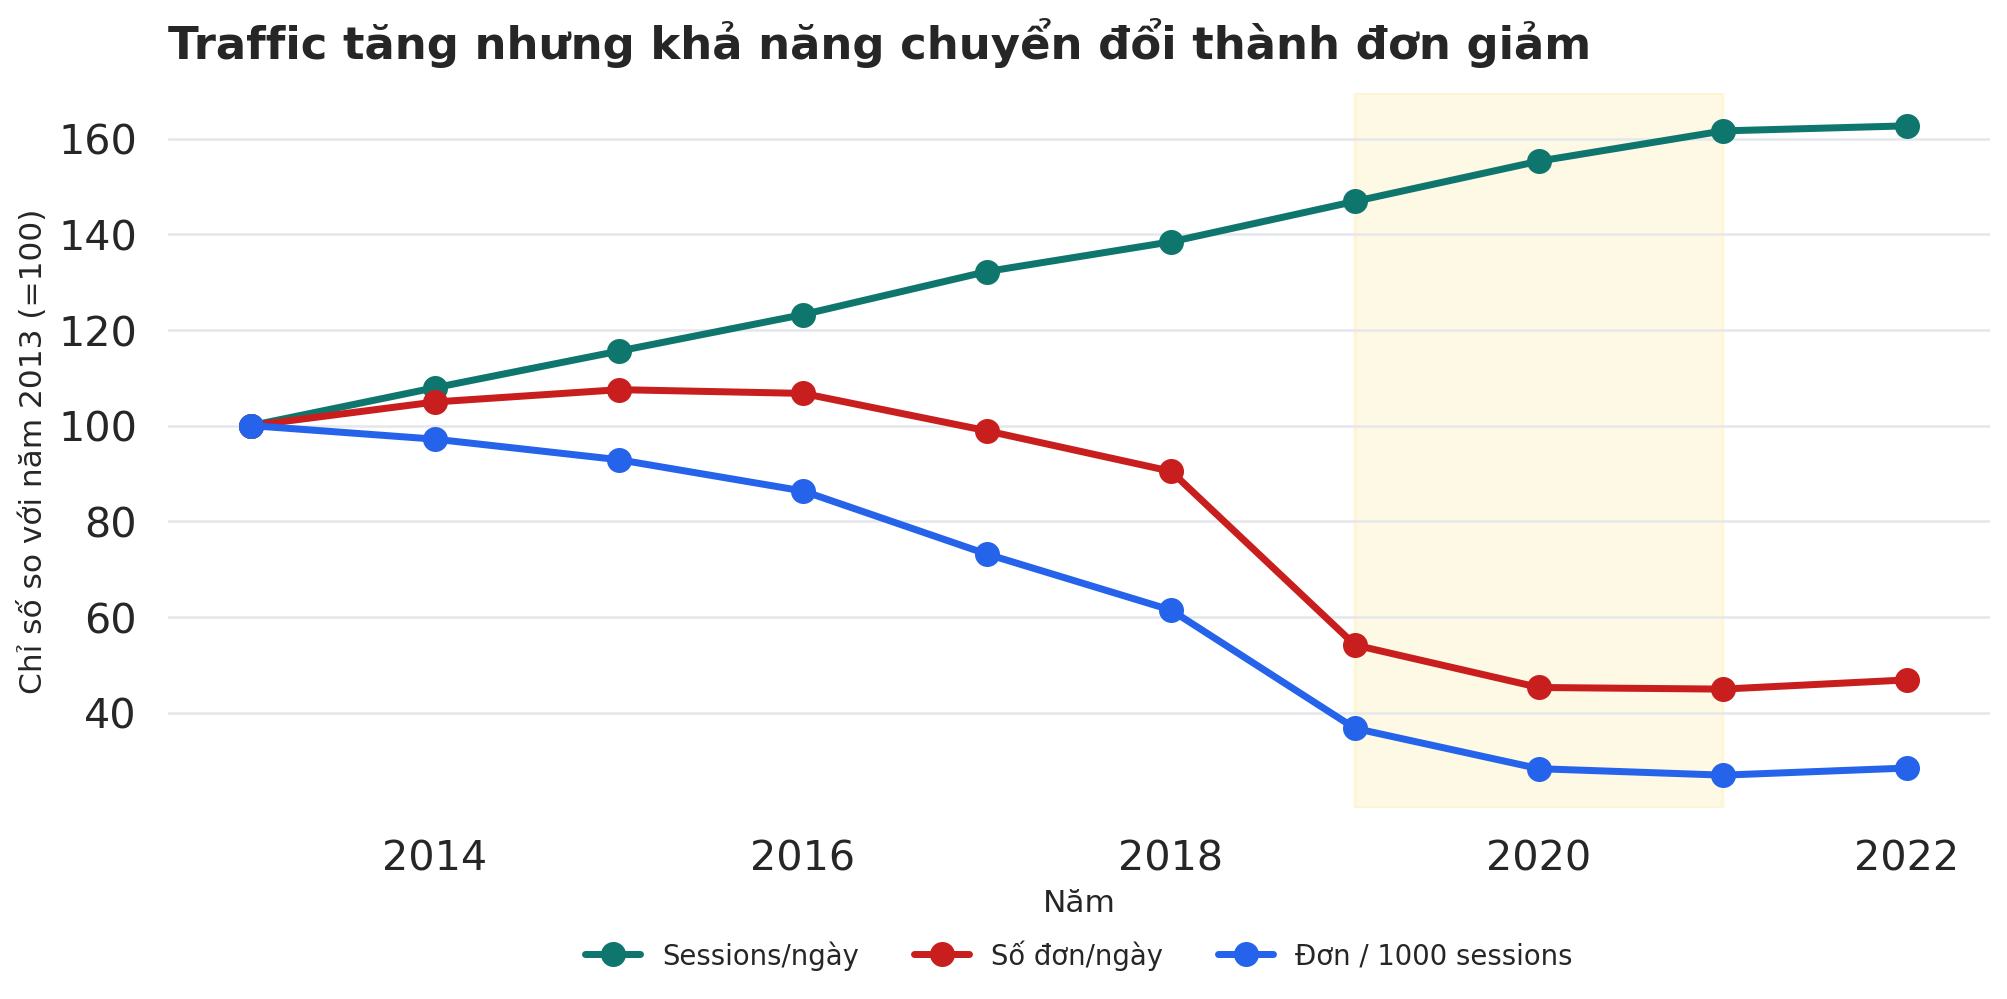

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Chuẩn bị dữ liệu
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "web_traffic" not in globals():
    web_traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"]
    )
    .groupby("order_id", as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"))
)

orders_full = orders.merge(order_value, on="order_id", how="left")

daily_orders = (
    orders_full.groupby("order_date", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

traffic_orders = web_traffic.merge(
    daily_orders,
    left_on="date",
    right_on="order_date",
    how="inner"
)

traffic_orders["year"] = traffic_orders["date"].dt.year
traffic_orders["don_tren_1000_sessions"] = (
    traffic_orders["so_don"] / traffic_orders["sessions"] * 1000
)

annual_funnel = (
    traffic_orders.groupby("year", as_index=False)
    .agg(
        sessions_tb_ngay=("sessions", "mean"),
        so_don_tb_ngay=("so_don", "mean"),
        doanh_thu_tb_ngay=("doanh_thu", "mean"),
        don_tren_1000_sessions=("don_tren_1000_sessions", "mean")
    )
)

# Chuẩn hóa 2013 = 100
base_year = 2013
for col in ["sessions_tb_ngay", "so_don_tb_ngay", "don_tren_1000_sessions"]:
    base_value = annual_funnel.loc[annual_funnel["year"] == base_year, col].iloc[0]
    annual_funnel[col + "_idx"] = annual_funnel[col] / base_value * 100

display(annual_funnel)

# =========================
# 2. Vẽ biểu đồ
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(11.5, 6.2), dpi=180)
plt.subplots_adjust(left=0.10, right=0.98, top=0.84, bottom=0.20)

# Tô nhẹ giai đoạn structural break / ngoại cảnh
ax.axvspan(2019, 2021, color="#FDE68A", alpha=0.22, zorder=0)

ax.plot(
    annual_funnel["year"],
    annual_funnel["sessions_tb_ngay_idx"],
    marker="o",
    linewidth=2.8,
    color="#0F766E",
    label="Sessions/ngày"
)

ax.plot(
    annual_funnel["year"],
    annual_funnel["so_don_tb_ngay_idx"],
    marker="o",
    linewidth=2.8,
    color="#C81E1E",
    label="Số đơn/ngày"
)

ax.plot(
    annual_funnel["year"],
    annual_funnel["don_tren_1000_sessions_idx"],
    marker="o",
    linewidth=2.8,
    color="#2563EB",
    label="Đơn / 1000 sessions"
)

ax.set_title(
    "Traffic tăng nhưng khả năng chuyển đổi thành đơn giảm",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Năm", fontsize=12.5)
ax.set_ylabel("Chỉ số so với năm 2013 (=100)", fontsize=12.5)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize=11
)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="y", color="#E5E7EB", linewidth=1)
ax.grid(axis="x", visible=False)

plt.show()


Ngoài mùa vụ theo tháng, dữ liệu còn cho thấy một structural break dài hạn: từ sau 2018, sessions tiếp tục tăng nhưng số đơn trên mỗi 1000 sessions giảm mạnh. Điều này cho thấy forecasting không chỉ cần học seasonality, mà còn phải xử lý sự thay đổi nền conversion theo thời gian.

,month,sessions_tb_ngay,so_don_tb_ngay,sessions,so_don,doanh_thu,don_tren_1000_sessions,doanh_thu_tren_1000_sessions,sessions_idx,orders_idx,sessions_idx_roll,orders_idx_roll,conversion_roll
108,2022-01-01,"16,290.61",55.45,505009,1719,"59,663,486.32",3.40,"118,143.41",87.46,26.36,98.81,28.57,3.26
109,2022-02-01,"23,700.71",77.93,663620,2182,"79,103,095.50",3.29,"119,199.38",127.25,37.04,108.24,32.31,3.38
110,2022-03-01,"33,475.97",136.48,1037755,4231,"137,537,949.28",4.08,"132,534.12",179.73,64.88,131.48,42.76,3.59
111,2022-04-01,"44,855.53",149.63,1345666,4489,"141,305,508.81",3.34,"105,007.86",240.82,71.13,182.60,57.68,3.57
112,2022-05-01,"41,955.26",131.48,1300613,4076,"139,027,887.16",3.13,"106,894.12",225.25,62.50,215.27,66.17,3.52
113,2022-06-01,"43,769.37",135.60,1313081,4068,"135,812,426.69",3.10,"103,430.35",234.99,64.46,233.69,66.03,3.19
114,2022-07-01,"34,441.00",100.71,1067671,3122,"98,141,777.72",2.92,"91,921.37",184.91,47.87,215.05,58.28,3.05
115,2022-08-01,"38,071.16",105.61,1180206,3274,"113,542,943.47",2.77,"96,206.04",204.40,50.20,208.10,54.18,2.93
116,2022-09-01,"27,224.73",88.10,816742,2643,"85,764,286.59",3.24,"105,007.81",146.17,41.88,178.49,46.65,2.98
117,2022-10-01,"21,205.84",67.65,657381,2097,"75,194,452.31",3.19,"114,384.89",113.85,32.16,154.81,41.41,3.07


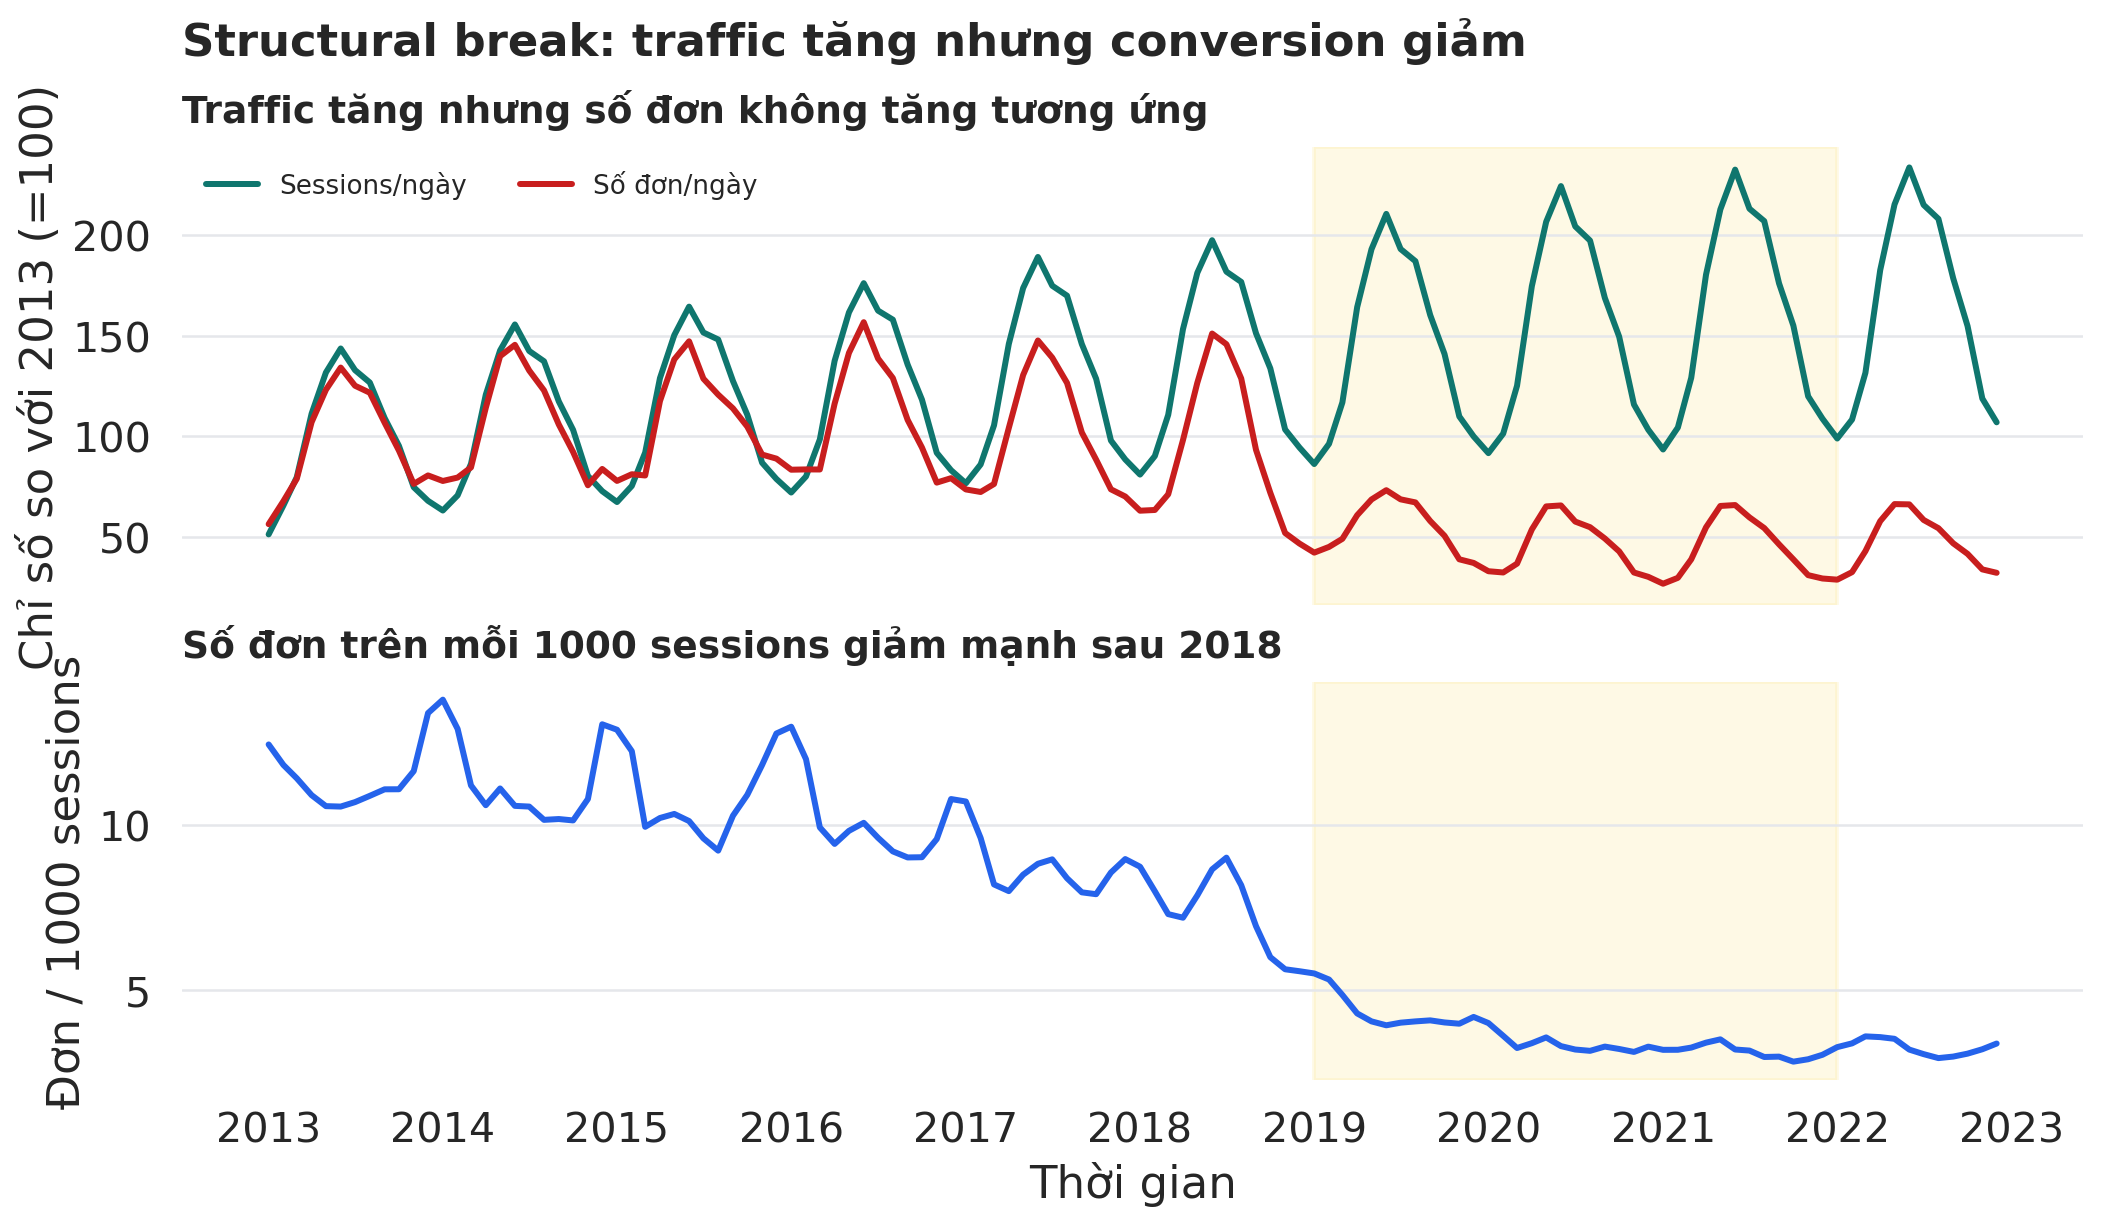

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# =========================
# 1. Chuẩn bị dữ liệu
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "web_traffic" not in globals():
    web_traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"]
    )
    .groupby("order_id", as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"))
)

orders_full = orders.merge(order_value, on="order_id", how="left")

daily_orders = (
    orders_full.groupby("order_date", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

daily_funnel = web_traffic.merge(
    daily_orders,
    left_on="date",
    right_on="order_date",
    how="inner"
)

daily_funnel["month"] = daily_funnel["date"].dt.to_period("M").dt.to_timestamp()

monthly_funnel = (
    daily_funnel.groupby("month", as_index=False)
    .agg(
        sessions_tb_ngay=("sessions", "mean"),
        so_don_tb_ngay=("so_don", "mean"),
        sessions=("sessions", "sum"),
        so_don=("so_don", "sum"),
        doanh_thu=("doanh_thu", "sum")
    )
)

monthly_funnel["don_tren_1000_sessions"] = (
    monthly_funnel["so_don"] / monthly_funnel["sessions"] * 1000
)

monthly_funnel["doanh_thu_tren_1000_sessions"] = (
    monthly_funnel["doanh_thu"] / monthly_funnel["sessions"] * 1000
)

# Chuẩn hóa về trung bình năm 2013 = 100
base = monthly_funnel[monthly_funnel["month"].dt.year == 2013]

monthly_funnel["sessions_idx"] = (
    monthly_funnel["sessions_tb_ngay"] / base["sessions_tb_ngay"].mean() * 100
)

monthly_funnel["orders_idx"] = (
    monthly_funnel["so_don_tb_ngay"] / base["so_don_tb_ngay"].mean() * 100
)

# Rolling 3 tháng để nhìn xu hướng mượt hơn
monthly_funnel["sessions_idx_roll"] = monthly_funnel["sessions_idx"].rolling(3, min_periods=1).mean()
monthly_funnel["orders_idx_roll"] = monthly_funnel["orders_idx"].rolling(3, min_periods=1).mean()
monthly_funnel["conversion_roll"] = monthly_funnel["don_tren_1000_sessions"].rolling(3, min_periods=1).mean()

display(monthly_funnel.tail(12))

# =========================
# 2. Vẽ biểu đồ
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 7.2),
    dpi=180,
    sharex=True,
    gridspec_kw={"height_ratios": [1.15, 1]}
)

plt.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.16, hspace=0.18)

# Tô giai đoạn structural break
for ax in axes:
    ax.axvspan(
        pd.Timestamp("2019-01-01"),
        pd.Timestamp("2021-12-31"),
        color="#FDE68A",
        alpha=0.22,
        zorder=0
    )

# Panel 1: Traffic vs Orders index
axes[0].plot(
    monthly_funnel["month"],
    monthly_funnel["sessions_idx_roll"],
    color="#0F766E",
    linewidth=2.4,
    label="Sessions/ngày"
)

axes[0].plot(
    monthly_funnel["month"],
    monthly_funnel["orders_idx_roll"],
    color="#C81E1E",
    linewidth=2.4,
    label="Số đơn/ngày"
)

axes[0].set_title(
    "Traffic tăng nhưng số đơn không tăng tương ứng",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

axes[0].set_ylabel("Chỉ số so với 2013 (=100)")
axes[0].legend(
    loc="upper left",
    frameon=False,
    fontsize=10.5,
    ncol=2
)

# Panel 2: Conversion
axes[1].plot(
    monthly_funnel["month"],
    monthly_funnel["conversion_roll"],
    color="#2563EB",
    linewidth=2.4
)

axes[1].set_title(
    "Số đơn trên mỗi 1000 sessions giảm mạnh sau 2018",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

axes[1].set_ylabel("Đơn / 1000 sessions")
axes[1].set_xlabel("Thời gian")

axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes:
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", color="#E5E7EB", linewidth=1)
    ax.grid(axis="x", visible=False)

fig.suptitle(
    "Structural break: traffic tăng nhưng conversion giảm",
    x=0.10,
    ha="left",
    fontsize=18,
    fontweight="bold"
)

plt.show()


In [70]:
period_df = monthly_funnel.copy()

period_df["giai_doan"] = pd.cut(
    period_df["month"].dt.year,
    bins=[2012, 2018, 2022],
    labels=["2013–2018", "2019–2022"]
)

break_summary = (
    period_df.groupby("giai_doan", as_index=False, observed=True)
    .agg(
        sessions_tb_ngay=("sessions_tb_ngay", "mean"),
        so_don_tb_ngay=("so_don_tb_ngay", "mean"),
        don_tren_1000_sessions=("don_tren_1000_sessions", "mean"),
        doanh_thu_tren_1000_sessions=("doanh_thu_tren_1000_sessions", "mean")
    )
)

display(break_summary)


,giai_doan,sessions_tb_ngay,so_don_tb_ngay,don_tren_1000_sessions,doanh_thu_tren_1000_sessions
0,2013–2018,"22,267.93",213.34,9.85,"233,459.98"
1,2019–2022,"29,169.38",100.55,3.48,"103,631.36"


Dữ liệu cho thấy một structural break rõ rệt sau giai đoạn 2018: lượng traffic trung bình tăng từ 22.3k lên 29.2k sessions/ngày nhưng số đơn trung bình lại giảm từ 213 xuống 101 đơn/ngày. Kết quả là hiệu quả chuyển đổi giảm mạnh, từ 9.85 xuống 3.48 đơn trên mỗi 1000 sessions, tương đương giảm khoảng 65%; doanh thu trên mỗi 1000 sessions cũng giảm khoảng 56%. Điều này cho thấy vấn đề tăng trưởng không nằm ở khả năng thu hút traffic, mà ở khả năng chuyển traffic thành đơn hàng. Giai đoạn này có thể chịu ảnh hưởng của yếu tố ngoại cảnh như COVID hoặc thay đổi hành vi mua sắm, nhưng dữ liệu nội bộ chỉ đủ để kết luận rằng doanh nghiệp đang gặp structural break ở tầng conversion. Vì vậy, doanh nghiệp nên ưu tiên audit lại funnel từ landing page đến checkout, đánh giá chất lượng traffic theo nguồn, và đưa biến structural break theo năm vào mô hình forecasting thay vì chỉ dựa vào seasonality.

#  **EDA chính thức**

Ba phân tích dưới đây trả lời ba câu hỏi cốt lõi của bài toán: doanh thu trong `sales.csv` thực chất đang đo điều gì, nhu cầu của doanh nghiệp biến động theo mùa ra sao, và đâu là rủi ro vận hành lớn nhất có thể làm doanh thu ghi nhận không chuyển hóa thành giao dịch hoàn tất. Cách sắp xếp này giúp nối trực tiếp EDA với phần dự báo doanh thu ở phía sau.


In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# Theme cho biểu đồ
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Đọc file
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(
    "order_items.csv",
    dtype={"promo_id": "string", "promo_id_2": "string"},
    low_memory=False
)
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv", parse_dates=["Date"])
shipments = pd.read_csv("shipments.csv", parse_dates=["ship_date", "delivery_date"])


# TRỤ 1


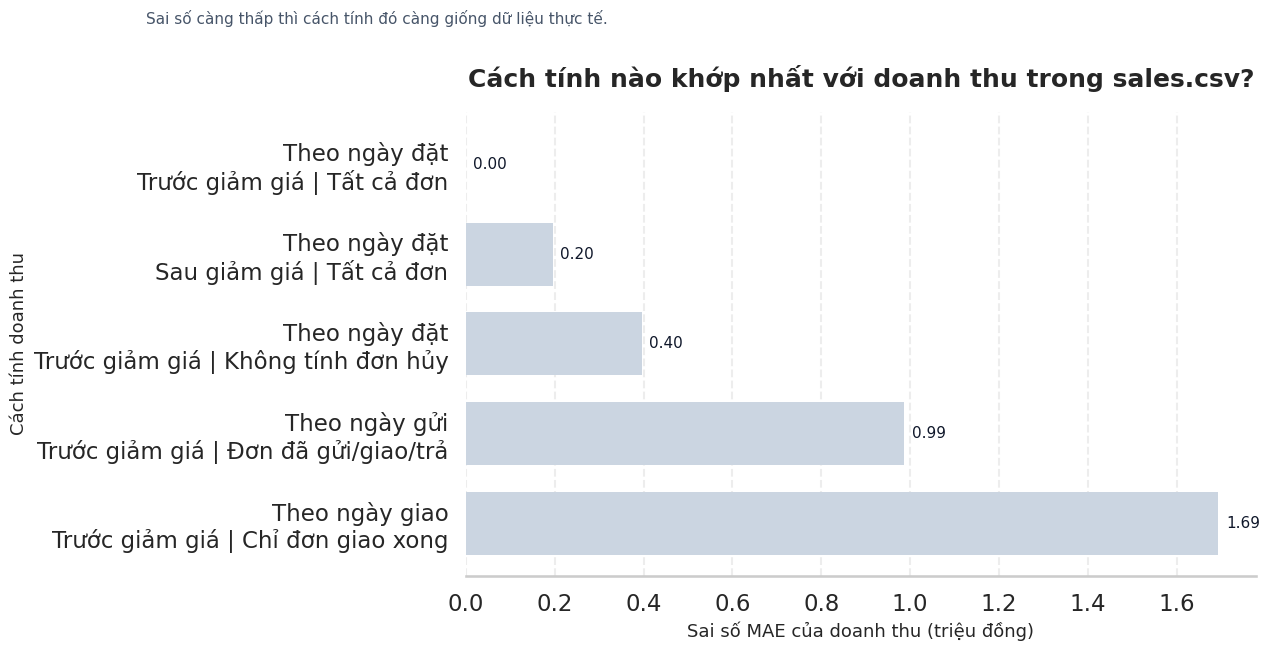

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_results = results.copy()
plot_results["MAE Revenue (triệu đồng)"] = plot_results["MAE Revenue"] / 1e6
plot_results = plot_results.sort_values("MAE Revenue (triệu đồng)", ascending=True).reset_index(drop=True)

label_map = {
    "order_date | gross | tất cả status": "Theo ngày đặt\nTrước giảm giá | Tất cả đơn",
    "order_date | net | tất cả status": "Theo ngày đặt\nSau giảm giá | Tất cả đơn",
    "order_date | gross | bỏ cancelled": "Theo ngày đặt\nTrước giảm giá | Không tính đơn hủy",
    "ship_date | gross | shipped/delivered/returned": "Theo ngày gửi\nTrước giảm giá | Đơn đã gửi/giao/trả",
    "delivery_date | gross | chỉ delivered": "Theo ngày giao\nTrước giảm giá | Chỉ đơn giao xong",
}

plot_results["Nhãn giả thuyết"] = plot_results["Giả thuyết"].map(label_map)

colors = ["#0F766E"] + ["#CBD5E1"] * (len(plot_results) - 1)

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    plot_results["Nhãn giả thuyết"],
    plot_results["MAE Revenue (triệu đồng)"],
    color=colors,
    edgecolor="none",
    height=0.7
)

ax.invert_yaxis()

ax.set_title(
    "Cách tính nào khớp nhất với doanh thu trong sales.csv?",
    fontsize=18,
    fontweight="bold",
    pad=18
)

fig.text(
    0.125, 0.92,
    "Sai số càng thấp thì cách tính đó càng giống dữ liệu thực tế.",
    fontsize=11,
    color="#475569"
)

ax.set_xlabel("Sai số MAE của doanh thu (triệu đồng)", fontsize=13)
ax.set_ylabel("Cách tính doanh thu", fontsize=13)


ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

max_val = plot_results["MAE Revenue (triệu đồng)"].max()
for bar, value in zip(bars, plot_results["MAE Revenue (triệu đồng)"]):
    ax.text(
        value + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.2f}",
        va="center",
        ha="left",
        fontsize=11,
        color="#0F172A"
    )

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


*Hình 1. So sánh sai số giữa `sales.csv` và các cách tính doanh thu khác nhau; MAE càng thấp thì cách tính càng khớp với dữ liệu thực tế.*




Kiểm định nhiều giả thuyết ghi nhận doanh thu cho thấy sales.csv khớp hoàn toàn với doanh thu gộp (gross revenue) được cộng theo order_date, trong khi các giả thuyết ghi nhận theo doanh thu sau giảm giá, theo ship_date, hoặc theo delivery_date đều tạo sai số lớn hơn rõ rệt. Điều này cho thấy doanh nghiệp đang ghi nhận doanh thu ngay tại thời điểm đơn được đặt, trước khi giao hàng hoàn tất và trước cả khi loại trừ các đơn bị hủy. Nói cách khác, chỉ số doanh thu hiện tại phản ánh giá trị đơn hàng được ghi nhận hơn là giá trị thực sự được hoàn tất sau fulfillment. Hệ quả là trong những giai đoạn tỷ lệ hủy đơn tăng cao, doanh nghiệp có thể đánh giá quá lạc quan hiệu quả kinh doanh nếu chỉ nhìn vào sales.csv. Vì vậy, doanh nghiệp nên tách riêng ít nhất hai lớp chỉ số: booked revenue tại thời điểm đặt đơn và realized revenue sau khi loại bỏ các đơn không hoàn tất, từ đó theo dõi chính xác hơn chất lượng tăng trưởng, hiệu quả vận hành và hiệu quả thật của các chiến dịch bán hàng.

# TRỤ 2

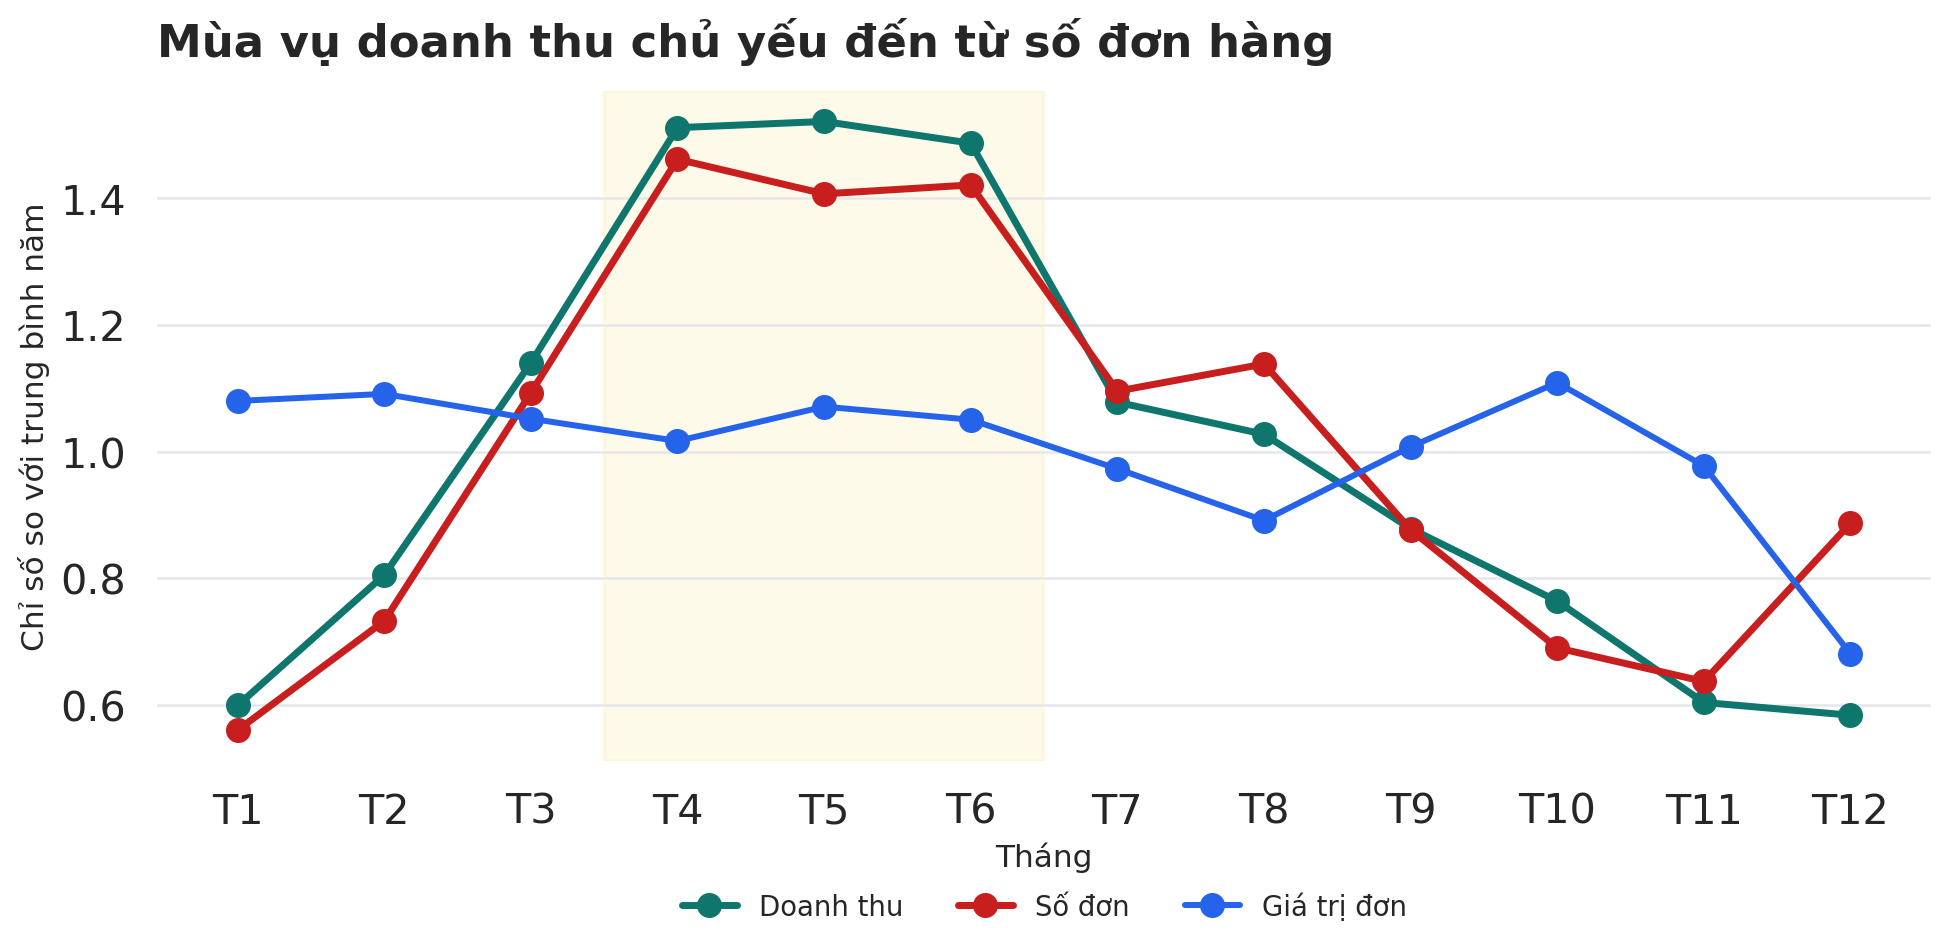

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Chuẩn bị dữ liệu
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"]
    )
    .groupby("order_id", as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"))
)

orders_full = (
    orders[["order_id", "order_date"]]
    .merge(order_value, on="order_id", how="left")
    .copy()
)

orders_full["ngay"] = orders_full["order_date"].dt.date
orders_full["thang"] = orders_full["order_date"].dt.month

daily_stats = (
    orders_full.groupby(["ngay", "thang"], as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

daily_stats["aov"] = daily_stats["doanh_thu"] / daily_stats["so_don"]

seasonality = (
    daily_stats.groupby("thang", as_index=False)
    .agg(
        so_don_tb_ngay=("so_don", "mean"),
        doanh_thu_tb_ngay=("doanh_thu", "mean"),
        aov_tb=("aov", "mean")
    )
)

# Chuẩn hóa để so trên cùng một trục
seasonality["chi_so_don"] = seasonality["so_don_tb_ngay"] / seasonality["so_don_tb_ngay"].mean()
seasonality["chi_so_doanh_thu"] = seasonality["doanh_thu_tb_ngay"] / seasonality["doanh_thu_tb_ngay"].mean()
seasonality["chi_so_aov"] = seasonality["aov_tb"] / seasonality["aov_tb"].mean()

month_labels = {
    1: "T1", 2: "T2", 3: "T3", 4: "T4", 5: "T5", 6: "T6",
    7: "T7", 8: "T8", 9: "T9", 10: "T10", 11: "T11", 12: "T12"
}
seasonality["thang_label"] = seasonality["thang"].map(month_labels)

# =========================
# 2. Vẽ biểu đồ sạch, không đè chữ
# =========================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(11.2, 6.2), dpi=180)
plt.subplots_adjust(left=0.10, right=0.98, top=0.84, bottom=0.24)

x = range(len(seasonality))

# Tô nhẹ mùa cao điểm T4-T6, không cần legend riêng
ax.axvspan(2.5, 5.5, color="#FDE68A", alpha=0.18, zorder=0)

ax.plot(
    x, seasonality["chi_so_doanh_thu"],
    marker="o", linewidth=2.8, color="#0F766E", label="Doanh thu"
)
ax.plot(
    x, seasonality["chi_so_don"],
    marker="o", linewidth=2.8, color="#C81E1E", label="Số đơn"
)
ax.plot(
    x, seasonality["chi_so_aov"],
    marker="o", linewidth=2.4, color="#2563EB", label="Giá trị đơn"
)

ax.set_title(
    "Mùa vụ doanh thu chủ yếu đến từ số đơn hàng",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Tháng", fontsize=12.5)
ax.set_ylabel("Chỉ số so với trung bình năm", fontsize=12.5)

ax.set_xticks(list(x))
ax.set_xticklabels(seasonality["thang_label"])

# Legend đặt ngoài plot ở dưới => không đè
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    fontsize=11
)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="y", color="#E5E7EB", linewidth=1)
ax.grid(axis="x", visible=False)

plt.show()


*Hình 2. Doanh thu và số đơn cùng đạt đỉnh trong giai đoạn T4–T6, trong khi giá trị đơn trung bình biến động ít hơn; điều này cho thấy mùa vụ doanh thu của doanh nghiệp chủ yếu được dẫn động bởi số đơn hàng.*

Doanh thu có mùa vụ rõ rệt theo tháng: mức cao nhất rơi vào T5 với khoảng 6.58 triệu đồng/ngày, trong khi thấp nhất là T12 với khoảng 2.52 triệu đồng/ngày, tức chênh lệch khoảng 2.60 lần. Khi tách doanh thu thành số đơn và giá trị đơn trung bình, doanh thu có tương quan rất cao với số đơn (0.95) nhưng tương quan yếu hơn nhiều với AOV (0.30), cho thấy mùa vụ chủ yếu được dẫn động bởi khối lượng đơn hàng chứ không phải giá trị mỗi đơn. Tuy nhiên, T12 là điểm trũng đặc biệt: đây không chỉ là tháng có doanh thu thấp nhất mà còn có tỷ lệ giảm giá cao nhất năm (17.21%) và tỷ lệ dòng hàng có khuyến mãi lên tới 86.17%, khiến net/item chỉ còn khoảng 2,566 đồng. Điều này hàm ý nếu chỉ nhìn doanh thu tổng, doanh nghiệp có thể bỏ sót vấn đề chất lượng doanh thu cuối năm. Vì vậy, mô hình forecasting cần đưa yếu tố tháng vào đặc trưng, còn về vận hành doanh nghiệp nên chuẩn bị năng lực xử lý đơn từ T3–T6 và kiểm soát khuyến mãi cuối năm theo hướng chọn lọc hơn thay vì phủ rộng đại trà.

# TRỤ 3

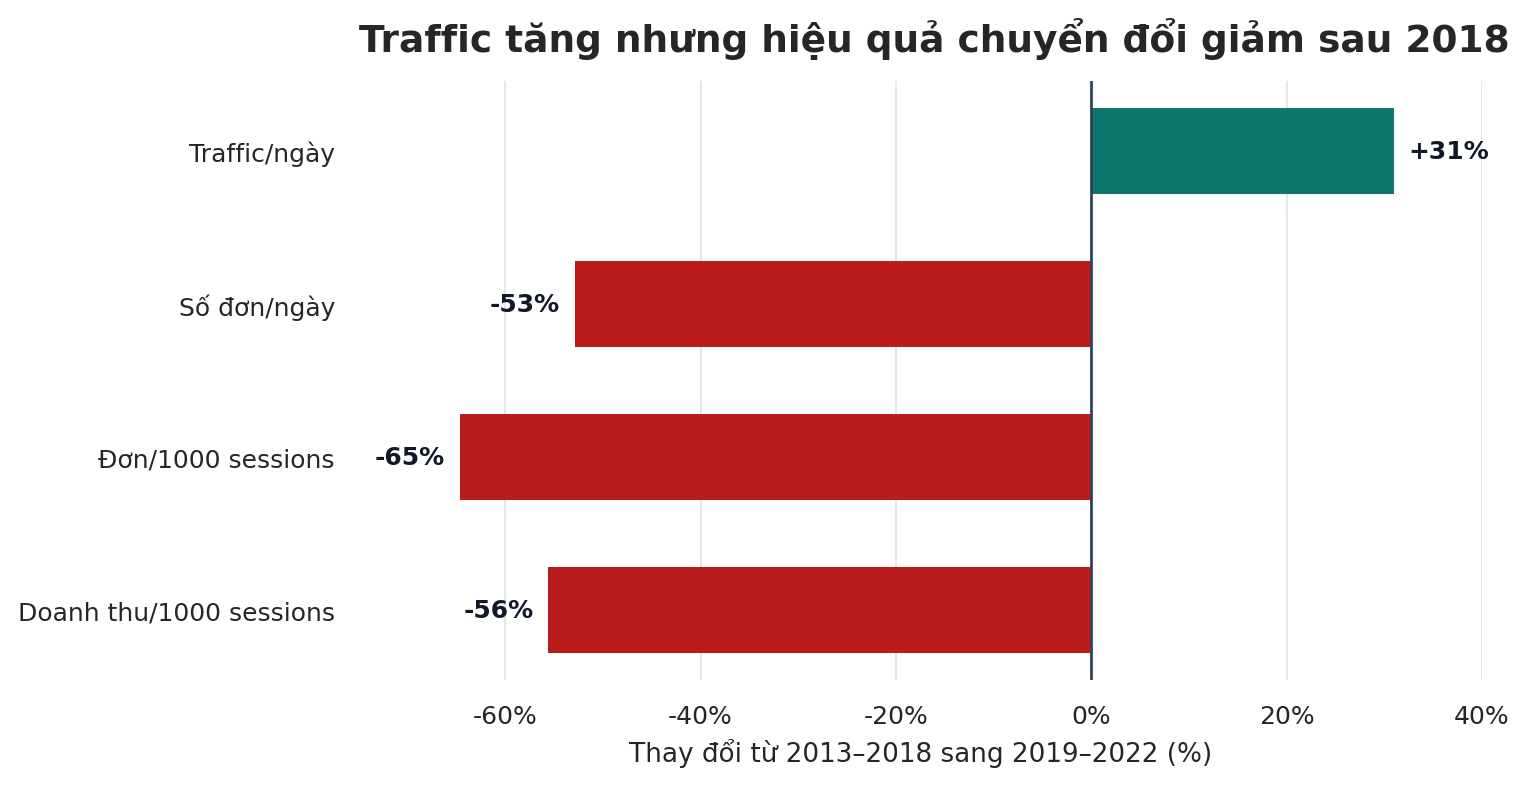

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# =========================
# 1. Chuẩn bị dữ liệu
# =========================
if "orders" not in globals():
    orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

if "web_traffic" not in globals():
    web_traffic = pd.read_csv("web_traffic.csv", parse_dates=["date"])

if "order_items" not in globals():
    order_items = pd.read_csv(
        "order_items.csv",
        dtype={"promo_id": "string", "promo_id_2": "string"},
        low_memory=False
    )

order_value = (
    order_items.assign(
        gross_revenue=lambda df: df["quantity"] * df["unit_price"]
    )
    .groupby("order_id", as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"))
)

orders_full = orders.merge(order_value, on="order_id", how="left")

daily_orders = (
    orders_full.groupby("order_date", as_index=False)
    .agg(
        so_don=("order_id", "count"),
        doanh_thu=("gross_revenue", "sum")
    )
)

daily_funnel = web_traffic.merge(
    daily_orders,
    left_on="date",
    right_on="order_date",
    how="inner"
)

daily_funnel["year"] = daily_funnel["date"].dt.year
daily_funnel["don_tren_1000_sessions"] = (
    daily_funnel["so_don"] / daily_funnel["sessions"] * 1000
)
daily_funnel["doanh_thu_tren_1000_sessions"] = (
    daily_funnel["doanh_thu"] / daily_funnel["sessions"] * 1000
)

daily_funnel["giai_doan"] = pd.cut(
    daily_funnel["year"],
    bins=[2012, 2018, 2022],
    labels=["2013–2018", "2019–2022"]
)

break_summary = (
    daily_funnel.groupby("giai_doan", as_index=False, observed=True)
    .agg(
        sessions_tb_ngay=("sessions", "mean"),
        so_don_tb_ngay=("so_don", "mean"),
        don_tren_1000_sessions=("don_tren_1000_sessions", "mean"),
        doanh_thu_tren_1000_sessions=("doanh_thu_tren_1000_sessions", "mean")
    )
)

before = break_summary[break_summary["giai_doan"] == "2013–2018"].iloc[0]
after = break_summary[break_summary["giai_doan"] == "2019–2022"].iloc[0]

change_df = pd.DataFrame({
    "Chỉ số": [
        "Traffic/ngày",
        "Số đơn/ngày",
        "Đơn/1000 sessions",
        "Doanh thu/1000 sessions"
    ],
    "Thay đổi (%)": [
        (after["sessions_tb_ngay"] / before["sessions_tb_ngay"] - 1) * 100,
        (after["so_don_tb_ngay"] / before["so_don_tb_ngay"] - 1) * 100,
        (after["don_tren_1000_sessions"] / before["don_tren_1000_sessions"] - 1) * 100,
        (after["doanh_thu_tren_1000_sessions"] / before["doanh_thu_tren_1000_sessions"] - 1) * 100,
    ]
})

# Sắp xếp để traffic ở trên cùng
change_df["order"] = [0, 1, 2, 3]
change_df = change_df.sort_values("order", ascending=True).reset_index(drop=True)

# =========================
# 2. Vẽ biểu đồ report-ready
# =========================
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(9.6, 5.2), dpi=180)
plt.subplots_adjust(left=0.30, right=0.95, top=0.82, bottom=0.18)

colors = [
    "#0F766E" if v > 0 else "#B91C1C"
    for v in change_df["Thay đổi (%)"]
]

bars = ax.barh(
    change_df["Chỉ số"],
    change_df["Thay đổi (%)"],
    color=colors,
    edgecolor="none",
    height=0.56
)

ax.invert_yaxis()
ax.axvline(0, color="#334155", linewidth=1.1)

# Nhãn giá trị
for bar, value in zip(bars, change_df["Thay đổi (%)"]):
    offset = 1.5 if value >= 0 else -1.5
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.0f}%",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=10,
        color="#111827",
        fontweight="bold"
    )

ax.set_title(
    "Traffic tăng nhưng hiệu quả chuyển đổi giảm sau 2018",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Thay đổi từ 2013–2018 sang 2019–2022 (%)", fontsize=10.5)
ax.set_ylabel("")

ax.set_xlim(-75, 40)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))

ax.tick_params(axis="both", labelsize=10)

ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
ax.grid(axis="y", visible=False)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.show()


*Hình 3. COD có tỷ lệ hủy đơn 16.00%, gần gấp đôi mặt bằng của các phương thức thanh toán còn lại; đường gạch biểu thị mức trung bình của nhóm không phải COD.*


Tỷ lệ hủy đơn khác biệt rõ rệt theo phương thức thanh toán. COD có tỷ lệ hủy đơn 16.00%, trong khi PayPal, Apple Pay, Credit Card và Bank Transfer chỉ dao động trong khoảng 7.89% - 8.06%, với mức trung bình là 7.99%. Chênh lệch 8.01 điểm phần trăm này cho thấy rủi ro hủy đơn không phân bố đều giữa các phương thức thanh toán mà tập trung nổi bật ở COD. Việc các phương thức còn lại có tỷ lệ hủy gần như ngang nhau gợi ý rằng nguyên nhân không nằm ở toàn bộ quy trình đặt hàng, mà chủ yếu đến từ đặc tính của COD, nơi mức cam kết mua của khách hàng thấp hơn. Nếu cơ cấu đơn hàng tiếp tục nghiêng nhiều về COD, doanh nghiệp có thể tiếp tục ghi nhận doanh thu ở thời điểm đặt đơn nhưng không chuyển hóa được tương ứng thành đơn hoàn tất, khiến tăng trưởng ở lớp doanh thu ghi nhận bị bào mòn bởi các đơn bị hủy. Vì vậy, doanh nghiệp nên quản trị COD như một nhóm rủi ro riêng, thông qua xác nhận đơn chặt hơn, áp điều kiện COD có chọn lọc, và tăng tỷ trọng thanh toán trả trước bằng ưu đãi hoặc tối ưu trải nghiệm thanh toán.

